# Toronto's Political Neighbourhoods — Interpreting Model 8F

This notebook picks up where `explore_neighbourhood_clusters.ipynb` left off. That notebook
built and compared many candidate clustering models of Toronto's 585 census tracts, using
their voting behaviour across three recent elections (the 2023 mayoral race, the 2025 Ontario
election, and the 2025 federal election). **This notebook does not re-run that model search.**
Its only job is to take the model that was chosen — **8F** — and interpret it in enough depth
to support a data-journalism piece on Toronto's political geography.

## What is Model 8F?

- **k = 5** clusters (five political neighbourhood groups).
- Each tract is described by a **50/50 blend** of two feature sets:
  - **City-relative deviations** — how a tract's vote shares and turnout compare to the
    *citywide* average, in percentage points.
  - **Within-riding-relative deviations** — how the same tract compares to the vote-weighted
    result of *its own* municipal ward / provincial riding / federal riding.
- Both halves are block-weighted (equal weight per election) and reduced with PCA before
  k-means clustering (`random_state=42`, `n_init=30`) — see §8E–8F of the reference notebook
  for the full derivation.

**Why this model, in one line:** a pure city-relative model conflates "safe NDP riding voting
slightly below its own historic norm" with "genuinely swingy tract" — it only sees the citywide
picture. A pure riding-residual model does the opposite: it can call a tract that is 70% NDP
in a heavily NDP riding "unremarkable" just because it matches its neighbours. The 50/50 blend
keeps both signals on the table at once, which is what lets a group like the high-turnout
Liberal/localist pocket (§3) show up as genuinely distinct rather than being absorbed into
whichever riding it happens to sit in.

## Reading guide

- **The unit of analysis is the census tract, not the voter.** A cluster is a description of
  what a *neighbourhood's aggregate vote* looked like, not a claim about the people who live
  there or how any individual voted.
- We do not claim or test causality between demographics and voting. Where a cluster's
  demographic profile lines up with its political profile, we describe it as an *association*,
  not a cause.
- We are careful with visible-minority, citizenship, immigration, and income variables —
  neutral, descriptive language throughout (e.g. "below the city average", "overrepresented"),
  never loaded terms like "immigrant neighbourhood" or "working-class" unless the numbers
  actually support that specific claim.

## A known data gap, addressed up front

The reference notebook computed the 8F cluster assignment **in memory** and exported only its
aggregate profile summary (`explore/8f_blend50_profiles.csv`) and static PNGs — it never wrote
a tract-level file with `ct_id → cluster` to disk. So the first thing this notebook does is
**deterministically reproduce** the 8F pipeline (same source data, same random seed, same
block-weighting and blending code) to regenerate that tract-level assignment. We then check the
result against the published `8f_blend50_profiles.csv` cluster-level numbers as a hard
correctness check before doing anything else with it.


In [1]:
import json
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from shapely.geometry import box as shapely_box
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
sns.set_style("whitegrid")


/home/aniket/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT = Path("../..")

# Tract-level election results (source for the 8F feature matrix; see reference notebook §1)
MAP_DIR    = ROOT / "data/toronto_election_turnout/interpolation/map"
RIDING_DIR = ROOT / "data/toronto_election_turnout/elections/raw"

# Reference notebook's saved outputs (used for QA / cross-checks, never as our only source)
CLUSTER_ROOT = ROOT / "data/clustering_neighbourhoods"
PROFILES_DIR = CLUSTER_ROOT / "profiles"
EXPLORE_DIR  = CLUSTER_ROOT / "explore"
REF_8F_PROFILES_CSV = EXPLORE_DIR / "8f_blend50_profiles.csv"

# Census
CENSUS_ADA_CSV       = CLUSTER_ROOT / "census/toronto-ada.csv"
CT_ADA_CROSSWALK_CSV = ROOT / "data/toronto_election_turnout/census/processed/crosswalks/statcan_2021_toronto_da_ct_ada_crosswalk.csv"

# ── Model 8F definition (must match explore_neighbourhood_clusters.ipynb §8E/§8F exactly) ──
K_CHOSEN          = 5      # number of clusters
ALPHA_CITY        = 0.5    # blend weight on the city-relative block (8F = 50/50)
RANDOM_STATE      = 42
PCA_VAR_THRESHOLD = 0.90   # retain PCA components explaining >=90% of block-weighted variance

# ── Election feature vocabulary (identical to the reference notebook) ───────────
MUN_CANDIDATE_KEYS = {
    "chow":     "Chow Olivia",
    "bailao":   "Bailão Ana",
    "saunders": "Saunders Mark",
    "furey":    "Furey Anthony",
    "matlow":   "Matlow Josh",
}
PROV_PARTY_KEYS = {
    "pc":      "progressive_conservative_party_of_ontario",
    "ndp":     "new_democratic_party_of_ontario",
    "liberal": "ontario_liberal_party",
    "green":   "green_party_of_ontario",
}
FED_PARTY_KEYS = {
    "liberal":      "liberal",
    "conservative": "conservative",
    "ndp":          "ndp_new_democratic_party",
    "green":        "green_party",
}

ALL_COLS = [
    "mun_turnout",
    "mun_chow", "mun_bailao", "mun_saunders", "mun_furey", "mun_matlow", "mun_other",
    "prov_turnout",
    "prov_pc", "prov_ndp", "prov_liberal", "prov_green", "prov_other",
    "fed_turnout",
    "fed_liberal", "fed_conservative", "fed_ndp", "fed_green", "fed_other",
]
TURNOUT_COLS    = ["mun_turnout", "prov_turnout", "fed_turnout"]
MUN_SHARE_COLS  = ["mun_chow", "mun_bailao", "mun_saunders", "mun_furey", "mun_matlow", "mun_other"]
PROV_SHARE_COLS = ["prov_pc", "prov_ndp", "prov_liberal", "prov_green", "prov_other"]
FED_SHARE_COLS  = ["fed_liberal", "fed_conservative", "fed_ndp", "fed_green", "fed_other"]
SHARE_COLS      = MUN_SHARE_COLS + PROV_SHARE_COLS + FED_SHARE_COLS

ELECTION_BLOCKS = {
    "municipal":  ["mun_turnout"]  + MUN_SHARE_COLS,
    "provincial": ["prov_turnout"] + PROV_SHARE_COLS,
    "federal":    ["fed_turnout"]  + FED_SHARE_COLS,
}

# ── Presentation ────────────────────────────────────────────────────────────────
# One colour per cluster ID, held fixed for every chart/map in this notebook.
PALETTE = ["#e63946", "#457b9d", "#2a9d8f", "#e9c46a", "#6a4c93"]

# Provisional labels (from the story brief). We confirm — and, if needed, correct — these
# against the actual 8F profile numbers in §2 below before relying on them anywhere else.
PROVISIONAL_LABELS = {
    0: "Centre-right / anti-NDP areas",
    1: "Progressive Chow–NDP core",
    2: "High-turnout Liberal/localist pocket",
    3: "Low-turnout PC-leaning areas",
    4: "Softer progressive / NDP-leaning belt",
}

# Census characteristics to extract from the long-form ADA file (IDs confirmed against the
# file directly in §6 — see the variable dictionary table there for full documentation).
CENSUS_CHAR_IDS = [
    1, 6, 37, 39, 50, 57, 113, 1414, 1416, 1465, 1467, 1522, 1523, 1683, 1684,
    1983, 1987, 1998, 2008, 2603, 2604, 2607, 2611, 2616,
]


## 2. Loading Model 8F

We rebuild the 8F pipeline in five steps, each mirroring a section of the reference notebook:

1. Extract raw vote shares + turnout per tract for all three elections (§1).
2. Compute city-relative deviations (§1).
3. Assign each tract to its municipal ward, provincial riding, and federal riding (§6).
4. Compute vote-weighted within-riding residuals (§8B).
5. Blend city-relative and riding-relative at 50/50, run PCA → k-means (k=5) (§8F).

Because every step uses the same input files, the same `RANDOM_STATE`, and the same code as
the reference notebook, the resulting cluster assignment should be bit-for-bit identical to
what produced `8f_blend50_profiles.csv` — we verify this explicitly below rather than assuming it.


In [3]:
# ── Step 1: extract raw vote shares + turnout per tract ──────────────────────────
def _parse_json(val):
    if isinstance(val, dict): return val
    if isinstance(val, str):  return json.loads(val) if val else {}
    return {}

def load_gdf(filename):
    gdf = gpd.read_file(MAP_DIR / filename)
    for col in ["party_votes", "candidate_votes", "top_candidates"]:
        if col in gdf.columns:
            gdf[col] = gdf[col].apply(_parse_json)
    return gdf

mun_gdf  = load_gdf("municipal_2023_mayor_ct_map.geojson")
prov_gdf = load_gdf("provincial_2025_ct_map.geojson")
fed_gdf  = load_gdf("federal_2025_ct_map.geojson")

def _safe_share(votes, total):
    return votes / total if total > 0 else 0.0

def extract_mun_features(row):
    cvotes, total = row["candidate_votes"], row["estimated_valid_candidate_votes"]
    s = {f"mun_{k}": _safe_share(cvotes.get(v, 0.0), total) for k, v in MUN_CANDIDATE_KEYS.items()}
    s["mun_other"] = max(0.0, 1.0 - sum(s.values())); s["mun_turnout"] = row["estimated_turnout"]
    return s

def extract_prov_features(row):
    pvotes, total = row["party_votes"], row["estimated_valid_candidate_votes"]
    s = {f"prov_{k}": _safe_share(pvotes.get(v, 0.0), total) for k, v in PROV_PARTY_KEYS.items()}
    s["prov_other"] = max(0.0, 1.0 - sum(s.values())); s["prov_turnout"] = row["estimated_turnout"]
    return s

def extract_fed_features(row):
    pvotes, total = row["party_votes"], row["estimated_valid_candidate_votes"]
    s = {f"fed_{k}": _safe_share(pvotes.get(v, 0.0), total) for k, v in FED_PARTY_KEYS.items()}
    s["fed_other"] = max(0.0, 1.0 - sum(s.values())); s["fed_turnout"] = row["estimated_turnout"]
    return s

with tqdm(total=3, desc="Extracting election features") as pbar:
    mun_feats  = pd.DataFrame([extract_mun_features(r)  for _, r in mun_gdf.iterrows()],  index=mun_gdf["ct_id"]); pbar.update()
    prov_feats = pd.DataFrame([extract_prov_features(r) for _, r in prov_gdf.iterrows()], index=prov_gdf["ct_id"]); pbar.update()
    fed_feats  = pd.DataFrame([extract_fed_features(r)  for _, r in fed_gdf.iterrows()],  index=fed_gdf["ct_id"]); pbar.update()

raw_df = mun_feats.join(prov_feats, how="inner").join(fed_feats, how="inner")[ALL_COLS]
raw_df = raw_df.fillna(raw_df.mean())

geom_df = mun_gdf.set_index("ct_id")[["geometry"]]
raw_gdf = gpd.GeoDataFrame(raw_df.join(geom_df, how="inner").reset_index(), geometry="geometry", crs=mun_gdf.crs)

# Same anomaly flag as the reference notebook: tracts where interpolation could not recover
# any named-party result in >=1 election (100% falls into "other"). Excluded from k-means
# fitting, then assigned to the nearest centroid after the fact.
_anom = (raw_gdf["mun_other"] >= 0.99) | (raw_gdf["prov_other"] >= 0.99) | (raw_gdf["fed_other"] >= 0.99)
anomaly_mask = _anom.values

print(f"Tracts loaded: {len(raw_gdf)}  |  CRS: {raw_gdf.crs}  |  Anomalous tracts excluded from fitting: {anomaly_mask.sum()}")


Extracting election features:   0%|          | 0/3 [00:00<?, ?it/s]

Tracts loaded: 585  |  CRS: EPSG:4326  |  Anomalous tracts excluded from fitting: 2


In [4]:
# ── Step 2: citywide (vote-weighted) benchmarks and city-relative deviations ──────
citywide = {}

mun_valid = mun_gdf["estimated_valid_candidate_votes"]
for k, v in MUN_CANDIDATE_KEYS.items():
    citywide[f"mun_{k}"] = mun_gdf["candidate_votes"].apply(lambda d, v=v: d.get(v, 0.0)).sum() / mun_valid.sum()
citywide["mun_other"]   = max(0.0, 1.0 - sum(citywide[f"mun_{k}"] for k in MUN_CANDIDATE_KEYS))
citywide["mun_turnout"] = (mun_gdf["estimated_turnout"] * mun_gdf["estimated_electors"]).sum() / mun_gdf["estimated_electors"].sum()

prov_valid = prov_gdf["estimated_valid_candidate_votes"]
for k, v in PROV_PARTY_KEYS.items():
    citywide[f"prov_{k}"] = prov_gdf["party_votes"].apply(lambda d, v=v: d.get(v, 0.0)).sum() / prov_valid.sum()
citywide["prov_other"]   = max(0.0, 1.0 - sum(citywide[f"prov_{k}"] for k in PROV_PARTY_KEYS))
citywide["prov_turnout"] = (prov_gdf["estimated_turnout"] * prov_gdf["estimated_electors"]).sum() / prov_gdf["estimated_electors"].sum()

fed_valid = fed_gdf["estimated_valid_candidate_votes"]
for k, v in FED_PARTY_KEYS.items():
    citywide[f"fed_{k}"] = fed_gdf["party_votes"].apply(lambda d, v=v: d.get(v, 0.0)).sum() / fed_valid.sum()
citywide["fed_other"]   = max(0.0, 1.0 - sum(citywide[f"fed_{k}"] for k in FED_PARTY_KEYS))
citywide["fed_turnout"] = (fed_gdf["estimated_turnout"] * fed_gdf["estimated_electors"]).sum() / fed_gdf["estimated_electors"].sum()

citywide_s = pd.Series(citywide)[ALL_COLS]
rel_df = raw_df.subtract(citywide_s)   # tract minus citywide, in vote-share units (x100 = pp)

print("Citywide benchmarks (%):")
print((citywide_s[TURNOUT_COLS + SHARE_COLS] * 100).round(1).to_string())


Citywide benchmarks (%):
mun_turnout         37.2
prov_turnout        42.6
fed_turnout         65.0
mun_chow            37.2
mun_bailao          32.5
mun_saunders         8.6
mun_furey            5.0
mun_matlow           4.9
mun_other           11.9
prov_pc             34.0
prov_ndp            23.3
prov_liberal        38.4
prov_green           2.7
prov_other           1.7
fed_liberal         58.4
fed_conservative    33.8
fed_ndp              6.4
fed_green            0.7
fed_other            0.7


In [5]:
# ── Step 3: assign each tract to its municipal ward / provincial riding / federal riding ──
# Ward polygons: dissolve 2023 polling subdivisions on the first 2 digits of AREA_LONG_CODE
subdiv_gdf = gpd.read_file(RIDING_DIR / "toronto_2023_subdivisions.geojson")
subdiv_gdf["ward"] = subdiv_gdf["AREA_LONG_CODE"].str[:2].astype(str)
ward_gdf = subdiv_gdf.dissolve(by="ward")

prov_ridings = gpd.read_file(RIDING_DIR / "ont_2025_ridings.geojson")
fed_ridings  = gpd.read_file(RIDING_DIR / "fed_2025_ridings.geojson")

def assign_ridings(ct_gdf, ward_gdf, prov_ridings, fed_ridings):
    # ct_id -> [mun_riding (ward code), prov_riding, fed_riding], centroid-based with
    # nearest-polygon fallback for any centroid that misses its target polygon.
    centroids_gdf = gpd.GeoDataFrame({"ct_id": ct_gdf["ct_id"].values},
                                      geometry=ct_gdf.geometry.centroid.values, crs=ct_gdf.crs)
    bbox = shapely_box(*ct_gdf.total_bounds)
    prov_local = prov_ridings[prov_ridings.geometry.intersects(bbox)][["RIDINGNAME", "geometry"]].reset_index(drop=True)
    fed_local  = fed_ridings[fed_ridings.geometry.intersects(bbox)][["RIDINGNAME", "geometry"]].reset_index(drop=True)
    ward_local = ward_gdf.reset_index()[["ward", "geometry"]].copy()

    def sjoin_with_fallback(pts, polys, id_col, out_col):
        joined = gpd.sjoin(pts, polys[[id_col, "geometry"]], how="left", predicate="within")
        joined = joined.drop_duplicates("ct_id")[["ct_id", id_col]]
        missing = joined[id_col].isna()
        if missing.any():
            for _, row in joined[missing].iterrows():
                pt = pts.loc[pts["ct_id"] == row["ct_id"], "geometry"].values[0]
                nearest = polys.geometry.distance(pt).idxmin()
                joined.loc[joined["ct_id"] == row["ct_id"], id_col] = polys.loc[nearest, id_col]
        return joined.rename(columns={id_col: out_col})

    ward_j = sjoin_with_fallback(centroids_gdf, ward_local, "ward",       "mun_riding")
    prov_j = sjoin_with_fallback(centroids_gdf, prov_local, "RIDINGNAME", "prov_riding")
    fed_j  = sjoin_with_fallback(centroids_gdf, fed_local,  "RIDINGNAME", "fed_riding")
    return ward_j.merge(prov_j, on="ct_id").merge(fed_j, on="ct_id")

riding_df = assign_ridings(raw_gdf, ward_gdf, prov_ridings, fed_ridings)
riding_df["ward_label"] = "Ward " + riding_df["mun_riding"].astype(int).astype(str)

print(f"Tracts assigned to a riding: {len(riding_df)}")
print(f"  Wards: {riding_df['mun_riding'].nunique()}  |  "
      f"Provincial ridings: {riding_df['prov_riding'].nunique()}  |  "
      f"Federal ridings: {riding_df['fed_riding'].nunique()}")


Tracts assigned to a riding: 585
  Wards: 25  |  Provincial ridings: 25  |  Federal ridings: 24


In [6]:
# ── Step 4: vote-weighted within-riding residuals (§8B of the reference notebook) ──
MUN_COLS, PROV_COLS, FED_COLS = ["mun_turnout"] + MUN_SHARE_COLS, ["prov_turnout"] + PROV_SHARE_COLS, ["fed_turnout"] + FED_SHARE_COLS

def compute_vote_weighted_residuals(raw_gdf, riding_df, mun_gdf, prov_gdf, fed_gdf, mun_cols, prov_cols, fed_cols):
    # Residual = tract share - vote-weighted riding-level share (party shares weighted by
    # valid votes cast in the tract; turnout weighted by registered electors).
    all_cols = mun_cols + prov_cols + fed_cols
    df = raw_gdf[all_cols].copy(); df.index = raw_gdf["ct_id"]
    df = df.join(riding_df.set_index("ct_id"))
    df["mun_votes"], df["mun_elecs"]   = mun_gdf.set_index("ct_id")["estimated_valid_candidate_votes"], mun_gdf.set_index("ct_id")["estimated_electors"]
    df["prov_votes"], df["prov_elecs"] = prov_gdf.set_index("ct_id")["estimated_valid_candidate_votes"], prov_gdf.set_index("ct_id")["estimated_electors"]
    df["fed_votes"], df["fed_elecs"]   = fed_gdf.set_index("ct_id")["estimated_valid_candidate_votes"], fed_gdf.set_index("ct_id")["estimated_electors"]

    def wtd_mean(value_cols, weight_col, group_col):
        w = df[weight_col].fillna(1.0)
        out = {col: ((df[col] * w).groupby(df[group_col]).transform("sum") /
                     w.groupby(df[group_col]).transform("sum")).values for col in value_cols}
        return pd.DataFrame(out, index=df.index)

    splits = {"mun": (mun_cols, "mun_votes", "mun_elecs", "mun_riding"),
              "prov": (prov_cols, "prov_votes", "prov_elecs", "prov_riding"),
              "fed": (fed_cols, "fed_votes", "fed_elecs", "fed_riding")}
    parts = []
    for cols, votes_col, elecs_col, riding_col in splits.values():
        s_cols = [c for c in cols if "turnout" not in c]
        t_cols = [c for c in cols if "turnout" in c]
        parts += [wtd_mean(s_cols, votes_col, riding_col), wtd_mean(t_cols, elecs_col, riding_col)]
    riding_avg = pd.concat(parts, axis=1)[all_cols]
    res = pd.DataFrame(df[all_cols].values - riding_avg.values, columns=all_cols, index=df.index)
    return res, riding_avg

vw_resid_df, vw_riding_avg = compute_vote_weighted_residuals(
    raw_gdf, riding_df, mun_gdf, prov_gdf, fed_gdf, MUN_COLS, PROV_COLS, FED_COLS
)
print("Vote-weighted within-riding residuals computed for", len(vw_resid_df), "tracts.")
print("Column means (should be close to 0, up to riding-size weighting):")
print(vw_resid_df.mean().round(4).to_string())


Vote-weighted within-riding residuals computed for 585 tracts.
Column means (should be close to 0, up to riding-size weighting):
mun_turnout         0.0025
mun_chow            0.0024
mun_bailao         -0.0067
mun_saunders        0.0003
mun_furey          -0.0006
mun_matlow         -0.0006
mun_other           0.0051
prov_turnout        0.0002
prov_pc             0.0006
prov_ndp           -0.0003
prov_liberal       -0.0020
prov_green         -0.0001
prov_other          0.0018
fed_turnout         0.0001
fed_liberal        -0.0022
fed_conservative   -0.0014
fed_ndp             0.0002
fed_green          -0.0001
fed_other           0.0035


In [7]:
# ── Step 5: block-weight, blend 50/50, PCA, k-means (k=5) — this IS Model 8F ──────
def apply_block_weights(X, col_names, blocks):
    X_out = X.copy().astype(float)
    for cols in blocks.values():
        idx = [col_names.index(c) for c in cols]
        X_out[:, idx] = StandardScaler().fit_transform(X_out[:, idx]) / np.sqrt(len(idx))
    return X_out

def apply_blend_weights(X_city, X_riding, col_names, blocks, alpha):
    X_c, X_r = np.zeros_like(X_city, dtype=float), np.zeros_like(X_riding, dtype=float)
    for cols in blocks.values():
        idx = [col_names.index(c) for c in cols]
        X_c[:, idx] = StandardScaler().fit_transform(X_city[:, idx])   / np.sqrt(len(idx))
        X_r[:, idx] = StandardScaler().fit_transform(X_riding[:, idx]) / np.sqrt(len(idx))
    return np.hstack([alpha * X_c, (1 - alpha) * X_r])

def assign_all(km, X_full, normal_idx, anomaly_mask):
    labels = np.empty(len(X_full), dtype=int)
    labels[normal_idx] = km.labels_
    for i in np.where(anomaly_mask)[0]:
        labels[i] = np.argmin(np.linalg.norm(km.cluster_centers_ - X_full[i], axis=1))
    return labels

X_city_vals   = rel_df[ALL_COLS].values.astype(float)
X_riding_vals = vw_resid_df[ALL_COLS].values.astype(float)
normal_idx    = np.where(~anomaly_mask)[0]

X_blend_8f = apply_blend_weights(X_city_vals, X_riding_vals, ALL_COLS, ELECTION_BLOCKS, ALPHA_CITY)

pca_probe = PCA(n_components=min(15, X_blend_8f.shape[1])).fit(X_blend_8f)
n_components_8f = int(np.searchsorted(np.cumsum(pca_probe.explained_variance_ratio_), PCA_VAR_THRESHOLD)) + 1
X_pca_8f = PCA(n_components=n_components_8f, random_state=RANDOM_STATE).fit_transform(X_blend_8f)

km_8f = KMeans(n_clusters=K_CHOSEN, n_init=30, random_state=RANDOM_STATE)
km_8f.fit(X_pca_8f[normal_idx])
labels_8f_raw = assign_all(km_8f, X_pca_8f, normal_idx, anomaly_mask)
silhouette_8f = silhouette_score(X_pca_8f[normal_idx], km_8f.labels_)

# Re-order cluster IDs by geographic centroid longitude (west -> east), exactly as the
# reference notebook does for every model variant — this is what makes "cluster 0" mean the
# same thing across the reference notebook's figures and this one.
centroid_x = np.array([raw_gdf.geometry.centroid.x.values[labels_8f_raw == c].mean() for c in range(K_CHOSEN)])
remap = {old: new for new, old in enumerate(np.argsort(centroid_x))}
labels_8f = np.array([remap[l] for l in labels_8f_raw])

raw_gdf["cluster_8f"] = labels_8f
cluster_sizes_8f = pd.Series(labels_8f).value_counts().sort_index()

print(f"Model 8F reproduced: {n_components_8f} PCA components (>= {PCA_VAR_THRESHOLD:.0%} variance), "
      f"silhouette = {silhouette_8f:.4f}")
print("Cluster sizes:", cluster_sizes_8f.to_dict())


Model 8F reproduced: 15 PCA components (>= 90% variance), silhouette = 0.1678
Cluster sizes: {0: 140, 1: 92, 2: 62, 3: 197, 4: 94}


### QA: does this match the published 8F profile exactly?

`explore/8f_blend50_profiles.csv` records the cluster-level average city-relative deviation
(in pp) and tract count for each of the five 8F groups, as computed inside the reference
notebook's live kernel. If our reproduction is correct, recomputing the same statistic from our
own `cluster_8f` labels should match those numbers to within floating-point noise.


In [8]:
ref_profiles = pd.read_csv(REF_8F_PROFILES_CSV, index_col=0)

check_profiles = pd.DataFrame(
    np.array([rel_df[ALL_COLS].values[labels_8f == c].mean(axis=0) for c in range(K_CHOSEN)]) * 100,
    columns=ALL_COLS, index=[f"50-50 {c}" for c in range(K_CHOSEN)],
)
max_abs_diff = np.abs(check_profiles.values - ref_profiles[ALL_COLS].values).max()
sizes_match = (cluster_sizes_8f.values == ref_profiles["n_tracts"].values).all()

print(f"Reproduced n_tracts per cluster : {cluster_sizes_8f.tolist()}")
print(f"Published n_tracts per cluster  : {ref_profiles['n_tracts'].tolist()}")
print(f"Cluster sizes match exactly     : {sizes_match}")
print(f"Max abs. difference in profile pp values vs. published CSV: {max_abs_diff:.2e}")
assert sizes_match and max_abs_diff < 1e-6, "8F reproduction does not match the reference notebook — stop and investigate."
print("\n✅ Reproduction confirmed identical to the reference notebook's Model 8F.")


Reproduced n_tracts per cluster : [140, 92, 62, 197, 94]
Published n_tracts per cluster  : [140, 92, 62, 197, 94]
Cluster sizes match exactly     : True
Max abs. difference in profile pp values vs. published CSV: 1.78e-15

✅ Reproduction confirmed identical to the reference notebook's Model 8F.


### Confirming the cluster labels

The provisional labels from the story brief were written from a general read of the model.
Before adopting them we check each cluster's largest over- and under-performances (in pp vs.
citywide) and its turnout deviation, to make sure the label actually matches the numbers.


In [9]:
for c in range(K_CHOSEN):
    row   = check_profiles.loc[f"50-50 {c}", SHARE_COLS]
    turn  = check_profiles.loc[f"50-50 {c}", TURNOUT_COLS]
    over  = row.nlargest(3)
    under = row.nsmallest(3)
    print(f"Cluster {c} — \"{PROVISIONAL_LABELS[c]}\"  (n={cluster_sizes_8f[c]} tracts)")
    print(f"  Turnout vs. city: "  + ", ".join(f"{col.replace('_turnout','')}={v:+.1f}pp" for col, v in turn.items()))
    print(f"  Over-performs:    " + ", ".join(f"{col}={v:+.1f}pp" for col, v in over.items()))
    print(f"  Under-performs:   " + ", ".join(f"{col}={v:+.1f}pp" for col, v in under.items()))
    print()

CLUSTER_LABELS = PROVISIONAL_LABELS  # confirmed by the printout above — see markdown note


Cluster 0 — "Centre-right / anti-NDP areas"  (n=140 tracts)
  Turnout vs. city: mun=+1.6pp, prov=+0.5pp, fed=-0.6pp
  Over-performs:    prov_pc=+12.9pp, fed_conservative=+10.5pp, mun_bailao=+9.9pp
  Under-performs:   prov_ndp=-16.5pp, mun_chow=-12.2pp, fed_liberal=-6.1pp

Cluster 1 — "Progressive Chow–NDP core"  (n=92 tracts)
  Turnout vs. city: mun=+7.8pp, prov=+5.9pp, fed=+4.2pp
  Over-performs:    prov_ndp=+30.1pp, mun_chow=+17.0pp, fed_ndp=+10.0pp
  Under-performs:   prov_pc=-19.0pp, fed_conservative=-14.3pp, prov_liberal=-11.3pp

Cluster 2 — "High-turnout Liberal/localist pocket"  (n=62 tracts)
  Turnout vs. city: mun=+7.9pp, prov=+5.3pp, fed=+7.9pp
  Over-performs:    prov_liberal=+12.3pp, mun_matlow=+5.0pp, mun_bailao=+3.7pp
  Under-performs:   prov_ndp=-8.3pp, mun_chow=-4.7pp, prov_pc=-3.8pp

Cluster 3 — "Low-turnout PC-leaning areas"  (n=197 tracts)
  Turnout vs. city: mun=-7.4pp, prov=-5.6pp, fed=-4.7pp
  Over-performs:    prov_pc=+9.0pp, mun_other=+5.5pp, fed_conservative=+2

**Confirmed.** Each label matches its numbers cleanly:

- **Cluster 0 — Centre-right / anti-NDP areas**: PC and Bailão over-perform, NDP and Chow
  clearly under-perform; turnout roughly average.
- **Cluster 1 — Progressive Chow–NDP core**: the single largest NDP over-performance of any
  group (+30pp provincially), Chow well above average, PC and Conservative well below — *and*
  the highest turnout of the five groups in all three elections.
- **Cluster 2 — High-turnout Liberal/localist pocket**: the standout on the Ontario and federal
  Liberal vote and on Matlow's municipal share, with the second-highest turnout — a smaller,
  locally-anchored group rather than a broad ideological bloc.
- **Cluster 3 — Low-turnout PC-leaning areas**: the largest group (197 tracts, a third of the
  city), defined less by an extreme partisan lean than by being clearly the lowest-turnout
  group in every single election, with a modest PC/Conservative tilt.
- **Cluster 4 — Softer progressive / NDP-leaning belt**: NDP and Chow lean positive but far
  less sharply than Cluster 1, and turnout sits close to the city average — a softer,
  lower-intensity version of the progressive core.

We'll keep referring to clusters by both their ID (0–4, fixed by west→east centroid order) and
this label for the rest of the notebook.


In [10]:
# ── Build the master analysis GeoDataFrame ────────────────────────────────────────
# One row per census tract: ID, geometry, cluster ID/label, riding assignments, raw vote
# shares, city-relative deviations, within-riding deviations, and turnout. Demographic
# columns are appended once the census join is built in §6-7.
tracts = raw_gdf[["ct_id", "geometry"] + ALL_COLS].copy()
tracts["cluster_8f"]    = labels_8f
tracts["cluster_label"] = tracts["cluster_8f"].map(CLUSTER_LABELS)
tracts = tracts.merge(riding_df, on="ct_id", how="left")

rel_named = rel_df.add_suffix("_vs_city").reset_index()
vw_named  = vw_resid_df.add_suffix("_vs_riding").reset_index()
tracts = tracts.merge(rel_named, on="ct_id", how="left").merge(vw_named, on="ct_id", how="left")

print(f"Master analysis table: {tracts.shape[0]} tracts x {tracts.shape[1]} columns")
print(f"CRS: {tracts.crs}  |  geometry type(s): {tracts.geom_type.unique().tolist()}")
tracts.head(3)


Master analysis table: 585 tracts x 65 columns
CRS: EPSG:4326  |  geometry type(s): ['MultiPolygon', 'Polygon']


,ct_id,geometry,mun_turnout,mun_chow,mun_bailao,mun_saunders,mun_furey,mun_matlow,mun_other,prov_turnout,...,prov_ndp_vs_riding,prov_liberal_vs_riding,prov_green_vs_riding,prov_other_vs_riding,fed_turnout_vs_riding,fed_liberal_vs_riding,fed_conservative_vs_riding,fed_ndp_vs_riding,fed_green_vs_riding,fed_other_vs_riding
0,5350001.00,"MULTIPOLYGON (((-79.30389 43.66419, -79.30397 ...",0.483020,0.516267,0.243748,0.044643,0.031523,0.054865,0.108955,0.511997,...,-0.042708,0.044545,-0.005595,0.004005,0.205328,0.029923,-0.002372,-0.028962,0.000857,0.000555
1,5350002.00,"MULTIPOLYGON (((-79.38662 43.61423, -79.38693 ...",0.602303,0.776824,0.094538,0.017861,0.021045,0.051247,0.038486,0.573935,...,0.348763,-0.239209,0.019264,-0.000818,0.272546,-0.070437,-0.171688,0.240019,0.002227,-0.000121
2,5350003.00,"MULTIPOLYGON (((-79.47039 43.63188, -79.46735 ...",0.394152,0.463646,0.286530,0.055260,0.052251,0.035852,0.106460,0.483344,...,0.004158,-0.007031,0.003855,0.000626,-0.275926,-0.064047,0.132029,-0.070625,0.002864,-0.000222


## 3. Electoral Profile of Each Cluster

Now that we trust the cluster assignment, we characterise what each of the five groups
actually voted for: raw vote shares, city-relative deviations, within-riding deviations, and
turnout, election by election.

Throughout this section (and the rest of the notebook), each cluster keeps the same colour
from `PALETTE`, and — where a chart benefits from a "spectrum" ordering rather than raw
cluster ID — we sort clusters by a simple **progressive ⟷ conservative lean score**
(provincial NDP + municipal Chow share, minus provincial PC + municipal Bailão share, both
city-relative). This is purely a presentation choice; cluster identity is unaffected.


In [11]:
LEAN_SCORE = (check_profiles["prov_ndp"] + check_profiles["mun_chow"]
              - check_profiles["prov_pc"] - check_profiles["mun_bailao"])
LEAN_SCORE.index = range(K_CHOSEN)
POLITICAL_ORDER = LEAN_SCORE.sort_values(ascending=False).index.tolist()
print("Political-lean order (most NDP/Chow-leaning first):")
for c in POLITICAL_ORDER:
    print(f"  Cluster {c} ({CLUSTER_LABELS[c]}): lean score = {LEAN_SCORE[c]:+.1f}")


Political-lean order (most NDP/Chow-leaning first):
  Cluster 1 (Progressive Chow–NDP core): lean score = +75.9
  Cluster 4 (Softer progressive / NDP-leaning belt): lean score = +33.4
  Cluster 2 (High-turnout Liberal/localist pocket): lean score = -13.0
  Cluster 3 (Low-turnout PC-leaning areas): lean score = -17.0
  Cluster 0 (Centre-right / anti-NDP areas): lean score = -51.6


In [12]:
# ── Cluster-level electoral summary table ─────────────────────────────────────────
rows = []
for c in range(K_CHOSEN):
    mask = tracts["cluster_8f"] == c
    row = {"cluster": c, "label": CLUSTER_LABELS[c],
           "n_tracts": int(mask.sum()), "pct_of_tracts": 100 * mask.mean()}
    for col in ALL_COLS:
        row[f"raw_{col}"] = tracts.loc[mask, col].mean() * 100
        row[f"city_rel_{col}"] = tracts.loc[mask, f"{col}_vs_city"].mean() * 100
        row[f"riding_rel_{col}"] = tracts.loc[mask, f"{col}_vs_riding"].mean() * 100
    rows.append(row)
electoral_summary = pd.DataFrame(rows).set_index("cluster")

turnout_table = electoral_summary[[f"raw_{c}" for c in TURNOUT_COLS] + [f"city_rel_{c}" for c in TURNOUT_COLS]].round(1)
turnout_table.columns = [c.replace("raw_", "").replace("_turnout", " turnout (%)") for c in [f"raw_{c}" for c in TURNOUT_COLS]] + \
                         [c.replace("city_rel_", "").replace("_turnout", " turnout, vs. city (pp)") for c in [f"city_rel_{c}" for c in TURNOUT_COLS]]
turnout_table.insert(0, "label", electoral_summary["label"])
turnout_table.insert(1, "n_tracts", electoral_summary["n_tracts"])
turnout_table


,label,n_tracts,mun turnout (%),prov turnout (%),fed turnout (%),"mun turnout, vs. city (pp)","prov turnout, vs. city (pp)","fed turnout, vs. city (pp)"
cluster,,,,,,,,
0,Centre-right / anti-NDP areas,140,38.8,43.1,64.4,1.6,0.5,-0.6
1,Progressive Chow–NDP core,92,45.0,48.5,69.2,7.8,5.9,4.2
2,High-turnout Liberal/localist pocket,62,45.1,48.0,72.9,7.9,5.3,7.9
3,Low-turnout PC-leaning areas,197,29.8,37.0,60.3,-7.4,-5.6,-4.7
4,Softer progressive / NDP-leaning belt,94,38.9,44.1,65.9,1.7,1.5,0.9


### Vote-share heatmaps: city-relative deviation vs. actual level

The first heatmap is the primary read — **deviation from the citywide average**, in
percentage points, green above / red below. The second shows the same clusters' **actual**
(raw) vote shares, which matters because two clusters can share a similar *deviation* while
sitting at very different absolute levels (e.g. a modestly-below-average NDP share in an
already-NDP-heavy city is not the same as a modestly-below-average share where the party barely
registers).


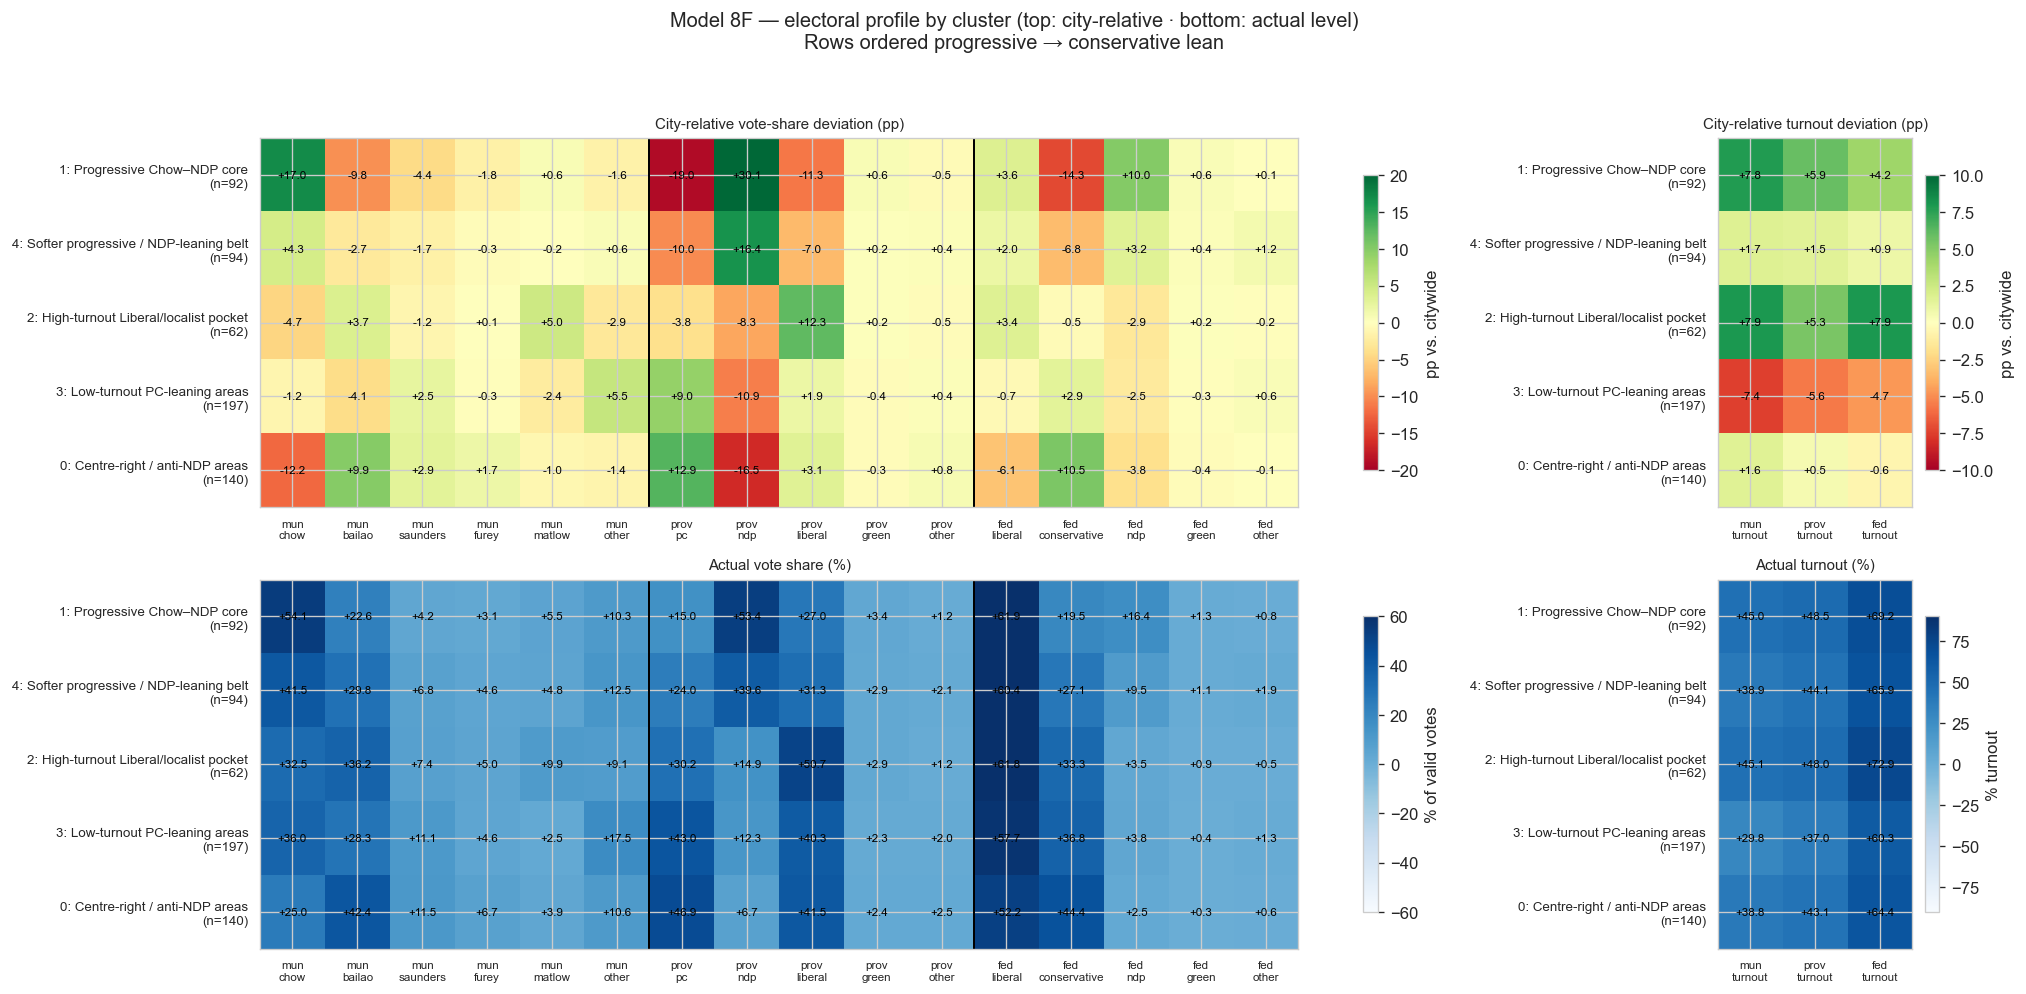

In [13]:
def draw_heatmap(ax, data, cols, title, vabs=20, cmap="RdYlGn"):
    im = ax.imshow(data[cols].values, cmap=cmap, aspect="auto", vmin=-vabs, vmax=vabs)
    for i in range(data.shape[0]):
        for j, col in enumerate(cols):
            ax.text(j, i, f"{data[col].iloc[i]:+.1f}", ha="center", va="center", fontsize=7, color="black")
    ax.set_xticks(range(len(cols))); ax.set_xticklabels([c.replace("_", "\n") for c in cols], fontsize=7)
    ax.set_yticks(range(len(data))); ax.set_yticklabels(data.index, fontsize=8)
    ax.set_title(title, fontsize=9)
    return im

def cluster_row_labels(order):
    return [f"{c}: {CLUSTER_LABELS[c]}\n(n={cluster_sizes_8f[c]})" for c in order]

city_rel_profiles = check_profiles.copy()
city_rel_profiles.index = range(K_CHOSEN)

raw_profiles = electoral_summary[[f"raw_{c}" for c in ALL_COLS]].copy()
raw_profiles.columns = ALL_COLS

fig, axes = plt.subplots(2, 2, figsize=(17, 8), gridspec_kw={"width_ratios": [len(SHARE_COLS), len(TURNOUT_COLS)]})
plot_order = POLITICAL_ORDER
im1 = draw_heatmap(axes[0, 0], city_rel_profiles.loc[plot_order].set_axis(cluster_row_labels(plot_order)), SHARE_COLS,
                    "City-relative vote-share deviation (pp)", vabs=20)
im2 = draw_heatmap(axes[0, 1], city_rel_profiles.loc[plot_order].set_axis(cluster_row_labels(plot_order)), TURNOUT_COLS,
                    "City-relative turnout deviation (pp)", vabs=10)
im3 = draw_heatmap(axes[1, 0], raw_profiles.loc[plot_order].set_axis(cluster_row_labels(plot_order)), SHARE_COLS,
                    "Actual vote share (%)", vabs=60, cmap="Blues")
im4 = draw_heatmap(axes[1, 1], raw_profiles.loc[plot_order].set_axis(cluster_row_labels(plot_order)), TURNOUT_COLS,
                    "Actual turnout (%)", vabs=90, cmap="Blues")
n_mun, n_prov = len(MUN_SHARE_COLS), len(PROV_SHARE_COLS)
for ax in [axes[0, 0], axes[1, 0]]:
    for x in [n_mun - 0.5, n_mun + n_prov - 0.5]:
        ax.axvline(x, color="black", lw=1.2)
fig.colorbar(im1, ax=axes[0, 0], label="pp vs. citywide", shrink=0.8)
fig.colorbar(im2, ax=axes[0, 1], label="pp vs. citywide", shrink=0.8)
fig.colorbar(im3, ax=axes[1, 0], label="% of valid votes", shrink=0.8)
fig.colorbar(im4, ax=axes[1, 1], label="% turnout", shrink=0.8)
fig.suptitle("Model 8F — electoral profile by cluster (top: city-relative · bottom: actual level)\n"
             "Rows ordered progressive → conservative lean", fontsize=12, y=1.03)
plt.tight_layout()
plt.show()


**Reading this.** The top-left panel is the clearest single picture of what separates the five
groups electorally: Cluster 1 and Cluster 4 sit on the NDP/Chow side, Cluster 2 stands out for
Liberal and Matlow support rather than a left-right position, and Clusters 0 and 3 sit on the
PC/Conservative/Bailão side — with Cluster 3's turnout deficit being the largest single number
anywhere in the top-right panel. The bottom row shows this isn't just about deviations: Cluster
1's actual NDP share (bottom-left) is genuinely high in absolute terms, not just high relative
to a low citywide baseline.


### Turnout, side by side

Turnout is one of the clearest and most consistent differentiators of the 8F solution — see
§4 below for a formal check of exactly how much it matters relative to the vote-share
variables. Here we simply look at the raw numbers, with the citywide average marked.


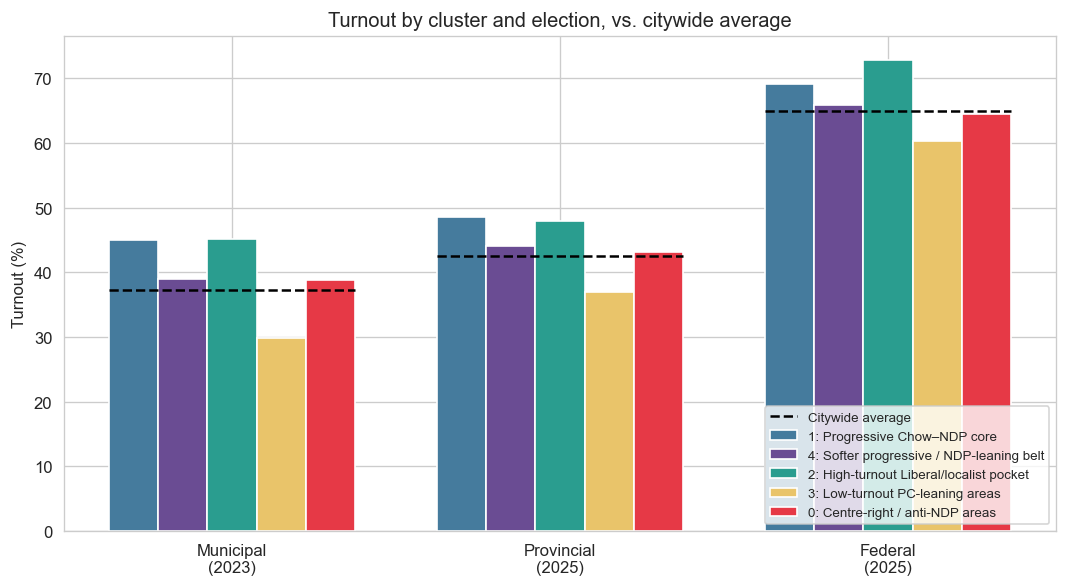

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(TURNOUT_COLS))
width = 0.15
for i, c in enumerate(POLITICAL_ORDER):
    vals = electoral_summary.loc[c, [f"raw_{t}" for t in TURNOUT_COLS]].values.astype(float)
    ax.bar(x + (i - 2) * width, vals, width, color=PALETTE[c], label=f"{c}: {CLUSTER_LABELS[c]}")
for i, t in enumerate(TURNOUT_COLS):
    ax.hlines(citywide_s[t] * 100, x[i] - 2.5 * width, x[i] + 2.5 * width, color="black", lw=1.5, linestyle="--")
ax.plot([], [], color="black", lw=1.5, linestyle="--", label="Citywide average")
ax.set_xticks(x); ax.set_xticklabels(["Municipal\n(2023)", "Provincial\n(2025)", "Federal\n(2025)"])
ax.set_ylabel("Turnout (%)")
ax.set_title("Turnout by cluster and election, vs. citywide average")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()


**Reading this.** Turnout ranks the same way in every one of the three elections: Cluster 2
highest or near-highest, then Cluster 1, then Cluster 4 and Cluster 0 near the city average,
and Cluster 3 clearly lowest each time. That consistency — the same ranking holding across a
municipal race, a provincial election, and a federal election with different campaigns,
candidates and turnout drivers — is itself a signal that turnout is tracking something durable
about these neighbourhoods, not one election's idiosyncrasies.


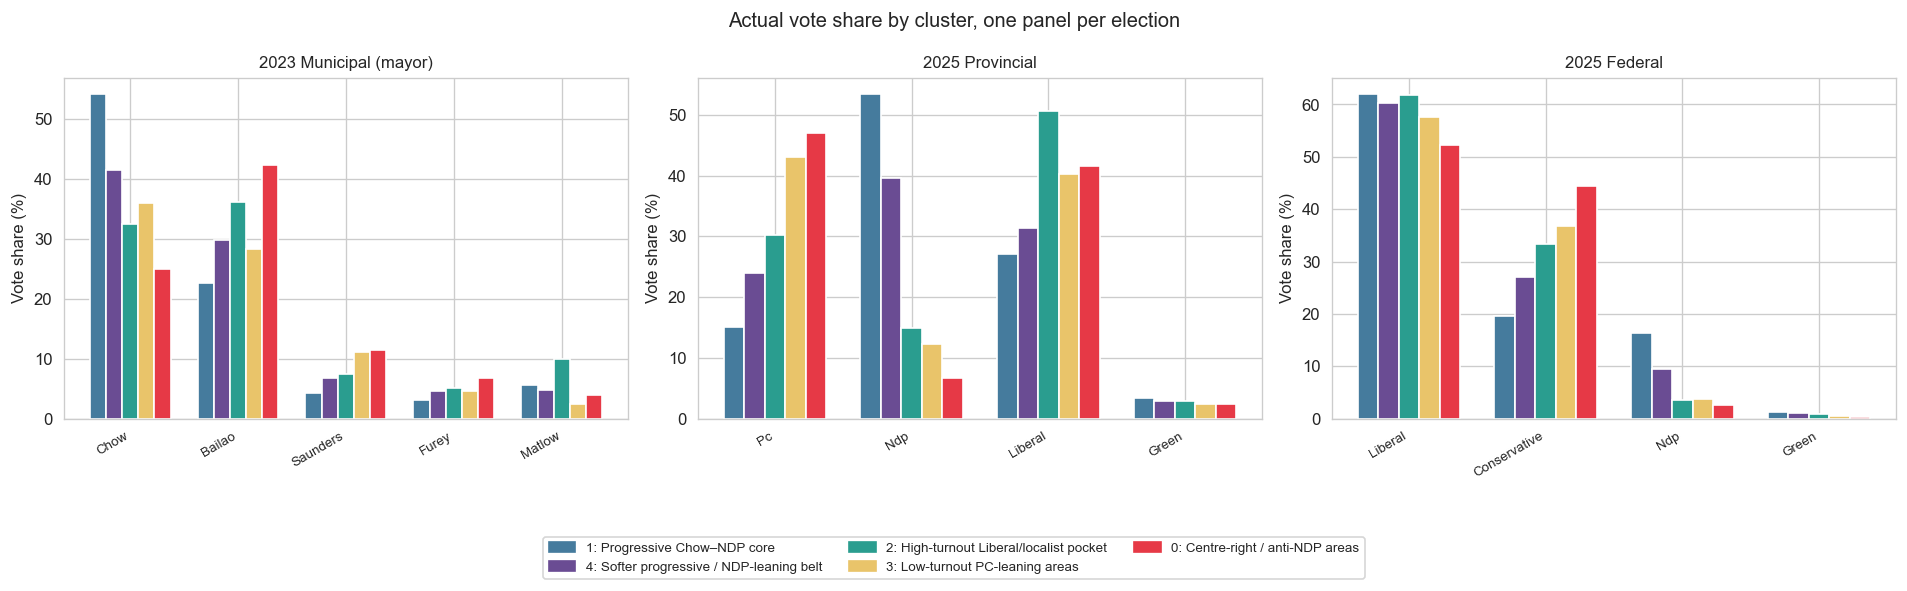

In [15]:
# ── Small multiples: vote share by party/candidate, one panel per election ───────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (title, cols, keys) in zip(axes, [
    ("2023 Municipal (mayor)", MUN_SHARE_COLS, MUN_CANDIDATE_KEYS),
    ("2025 Provincial",        PROV_SHARE_COLS, PROV_PARTY_KEYS),
    ("2025 Federal",           FED_SHARE_COLS,  FED_PARTY_KEYS),
]):
    plot_cols = [c for c in cols if not c.endswith("_other")]
    x = np.arange(len(plot_cols))
    width = 0.15
    for i, c in enumerate(POLITICAL_ORDER):
        vals = electoral_summary.loc[c, [f"raw_{col}" for col in plot_cols]].values.astype(float)
        ax.bar(x + (i - 2) * width, vals, width, color=PALETTE[c])
    ax.set_xticks(x); ax.set_xticklabels([c.split("_", 1)[1].capitalize() for c in plot_cols], rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Vote share (%)"); ax.set_title(title, fontsize=10)
handles = [mpatches.Patch(color=PALETTE[c], label=f"{c}: {CLUSTER_LABELS[c]}") for c in POLITICAL_ORDER]
fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.02), ncol=3, fontsize=8)
fig.suptitle("Actual vote share by cluster, one panel per election", fontsize=12)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


**Reading this.** The municipal panel makes Cluster 2's identity obvious at a glance — it is
the only group where Matlow clearly outpolls Saunders, and it holds a real Chow share too,
consistent with a "localist" pattern rather than a simple left-right one. The provincial and
federal panels line up more conventionally: Clusters 1 and 4 lead on NDP, Clusters 0 and 3 lead
on PC/Conservative, and Cluster 2 is again the outlier — this time on the Liberal column in
both the provincial and federal panels.


In [16]:
# ── Table: top over/under-performing party or candidate per cluster (city-relative) ──
top_rows = []
for c in range(K_CHOSEN):
    row = check_profiles.loc[f"50-50 {c}", SHARE_COLS]
    top_rows.append({
        "cluster": c, "label": CLUSTER_LABELS[c],
        "top_overperformance": f"{row.idxmax()} ({row.max():+.1f}pp)",
        "2nd_overperformance": f"{row.nlargest(2).index[1]} ({row.nlargest(2).iloc[1]:+.1f}pp)",
        "top_underperformance": f"{row.idxmin()} ({row.min():+.1f}pp)",
        "2nd_underperformance": f"{row.nsmallest(2).index[1]} ({row.nsmallest(2).iloc[1]:+.1f}pp)",
    })
pd.DataFrame(top_rows).set_index("cluster")


,label,top_overperformance,2nd_overperformance,top_underperformance,2nd_underperformance
cluster,,,,,
0,Centre-right / anti-NDP areas,prov_pc (+12.9pp),fed_conservative (+10.5pp),prov_ndp (-16.5pp),mun_chow (-12.2pp)
1,Progressive Chow–NDP core,prov_ndp (+30.1pp),mun_chow (+17.0pp),prov_pc (-19.0pp),fed_conservative (-14.3pp)
2,High-turnout Liberal/localist pocket,prov_liberal (+12.3pp),mun_matlow (+5.0pp),prov_ndp (-8.3pp),mun_chow (-4.7pp)
3,Low-turnout PC-leaning areas,prov_pc (+9.0pp),mun_other (+5.5pp),prov_ndp (-10.9pp),mun_bailao (-4.1pp)
4,Softer progressive / NDP-leaning belt,prov_ndp (+16.4pp),mun_chow (+4.3pp),prov_pc (-10.0pp),prov_liberal (-7.0pp)


## 4. What Splits the City?

The profile heatmap already suggests answers, but we can be more systematic: for each of the
18 underlying features (turnout + vote share x 3 elections), how much of its variance across
all 585 tracts is *between* the five clusters, versus *within* them? A feature with a high
between/total ratio is one the clustering leans on heavily to tell groups apart; a feature with
a low ratio varies just as much within clusters as between them, and isn't doing much
differentiating work.

This is a description of the fitted clustering solution, not a causal or predictive claim.


In [17]:
def between_within_variance(df_vals, labels, k):
    # Between-cluster variance share for each column: SS_between / SS_total.
    grand_mean = df_vals.mean(axis=0)
    ss_total = ((df_vals - grand_mean) ** 2).sum(axis=0)
    ss_between = np.zeros(df_vals.shape[1])
    for c in range(k):
        mask = labels == c
        if mask.sum() == 0:
            continue
        cluster_mean = df_vals[mask].mean(axis=0)
        ss_between += mask.sum() * (cluster_mean - grand_mean) ** 2
    return np.divide(ss_between, ss_total, out=np.zeros_like(ss_total), where=ss_total > 0)

# Diagnostics run on the same block-weighted, blended feature space the k-means actually saw,
# so "most differentiating" reflects what the model used, not the raw unweighted vote shares.
bw_ratio = between_within_variance(X_blend_8f, labels_8f, K_CHOSEN)
blended_col_names = [f"{c}_city" for c in ALL_COLS] + [f"{c}_riding" for c in ALL_COLS]
diff_table = pd.DataFrame({"feature": blended_col_names, "between_var_share": bw_ratio}) \
    .sort_values("between_var_share", ascending=False).reset_index(drop=True)

# Same diagnostic on the raw (unweighted) city-relative shares, for an interpretable pp range.
raw_range = pd.Series(
    {col: check_profiles[col].max() - check_profiles[col].min() for col in ALL_COLS},
    name="max_minus_min_pp",
)

print("Top 10 most differentiating features (share of variance that is between-cluster):")
diff_table.head(10)


Top 10 most differentiating features (share of variance that is between-cluster):


,feature,between_var_share
0,prov_ndp_city,0.748699
1,prov_pc_city,0.700913
2,fed_ndp_city,0.673520
3,fed_conservative_city,0.665870
4,mun_chow_city,0.657300
5,mun_saunders_city,0.657118
6,mun_bailao_city,0.515418
7,prov_turnout_city,0.456137
8,mun_furey_city,0.425456
9,fed_green_city,0.420744


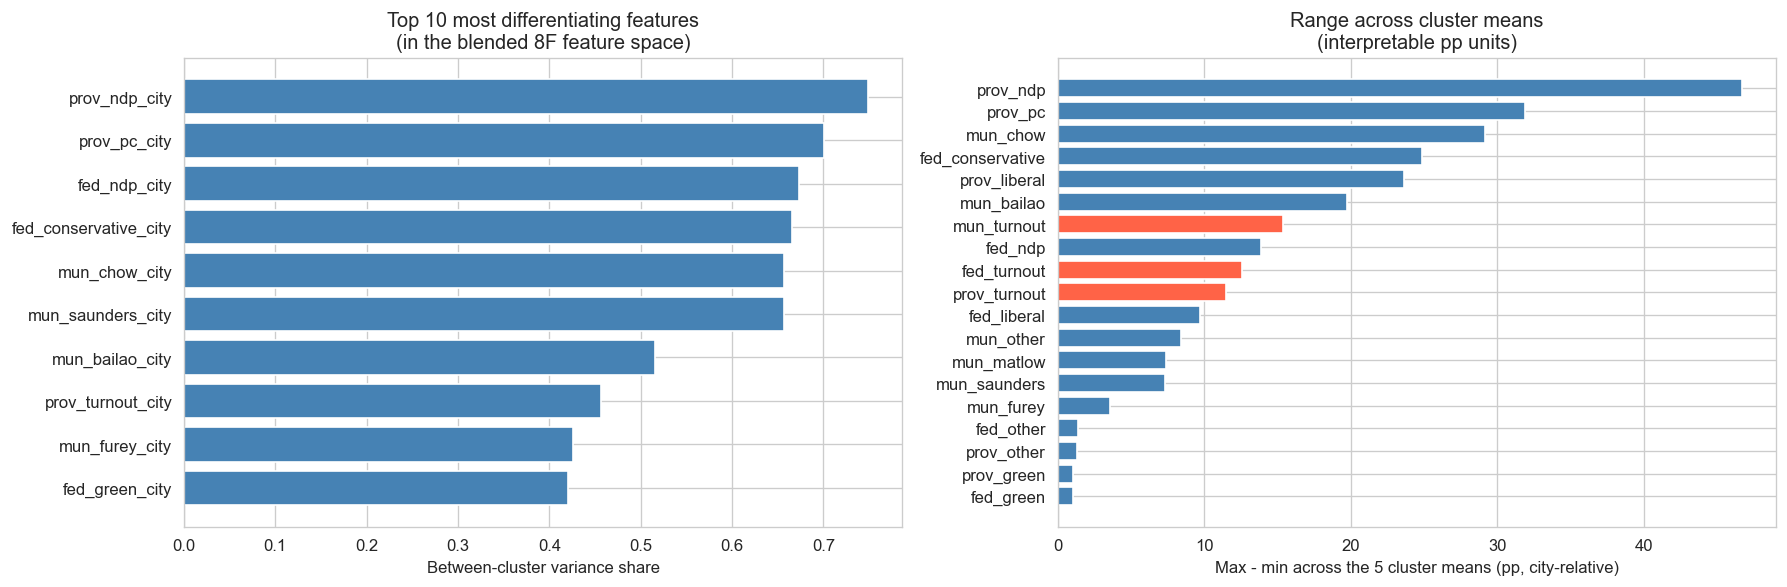

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top10 = diff_table.head(10)
axes[0].barh(top10["feature"][::-1], top10["between_var_share"][::-1], color="steelblue")
axes[0].set_xlabel("Between-cluster variance share")
axes[0].set_title("Top 10 most differentiating features\n(in the blended 8F feature space)")

range_sorted = raw_range.sort_values(ascending=False)
colors = ["tomato" if "turnout" in c else "steelblue" for c in range_sorted.index]
axes[1].barh(range_sorted.index[::-1], range_sorted.values[::-1], color=colors[::-1])
axes[1].set_xlabel("Max - min across the 5 cluster means (pp, city-relative)")
axes[1].set_title("Range across cluster means\n(interpretable pp units)")
plt.tight_layout()
plt.show()


**Reading this.** Provincial NDP and PC vote share dominate the "most differentiating" list on
both measures — consistent with §3, where the sharpest cross-cluster contrasts were on those
two columns. Turnout variables (tomato bars, right panel) show up mid-table rather than at the
very top: they matter — Cluster 3's turnout deficit and Cluster 2's turnout surplus are both
real and consistent — but the single biggest range-in-pp terms belongs to partisan vote share,
not turnout. In other words: **the 8F clusters are primarily a partisan-lean split with a
turnout dimension layered on top, not a turnout-first split with partisanship as a footnote.**


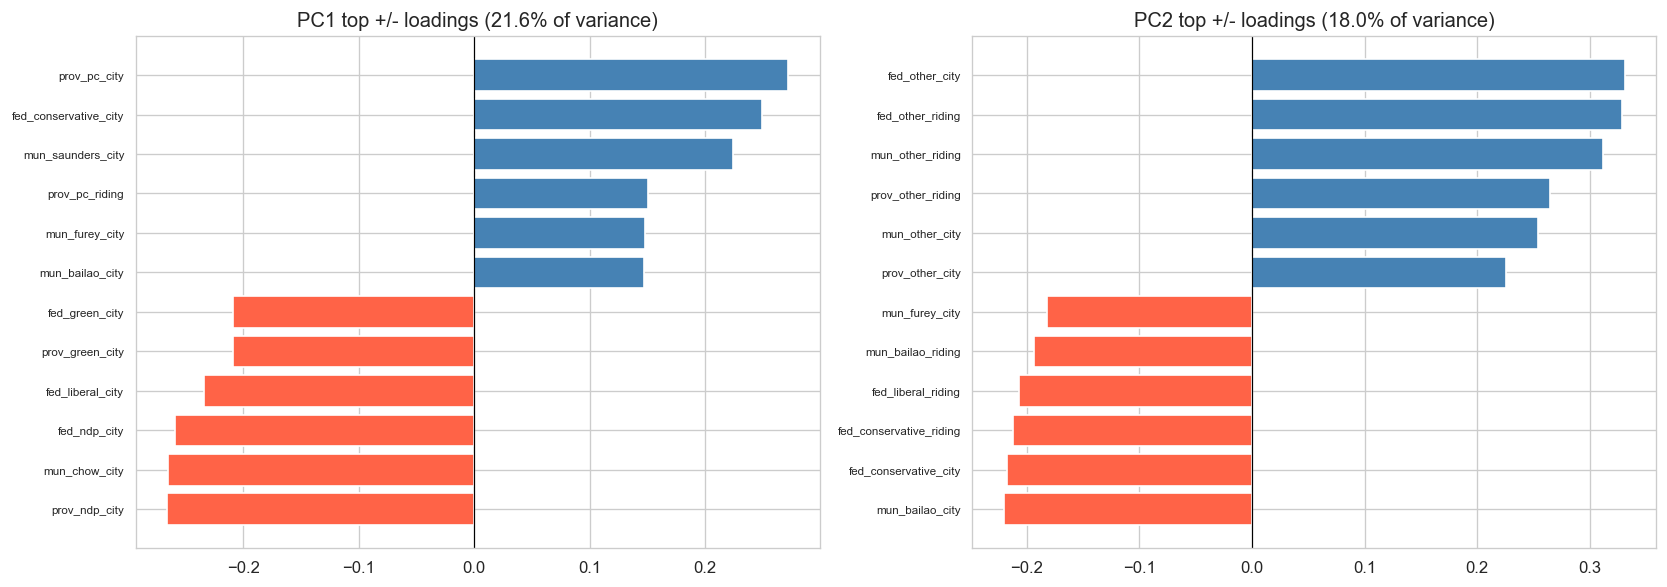

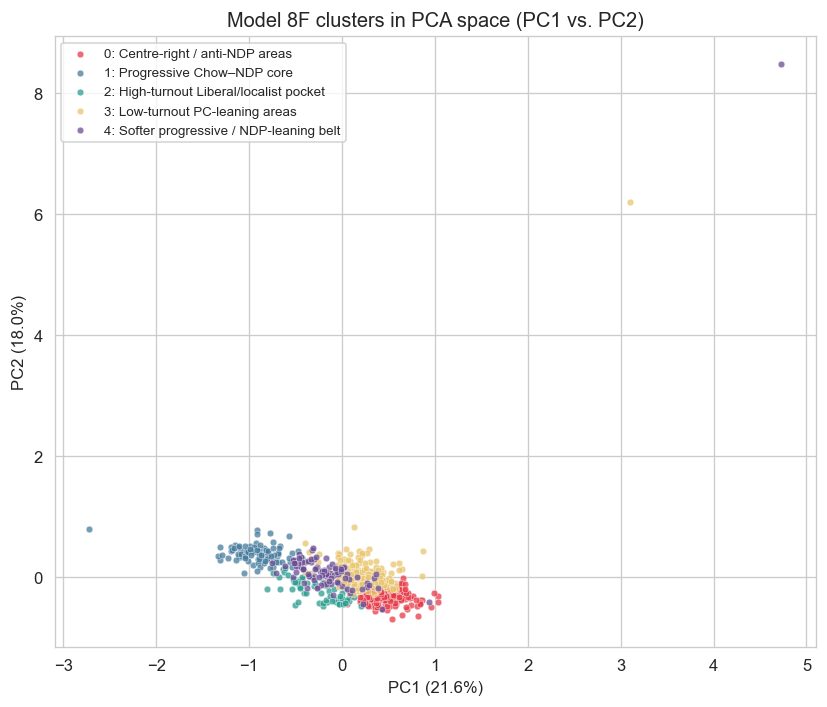

In [19]:
# ── PCA loadings and scatter for the blended 8F feature space ────────────────────
pca_8f = PCA(n_components=min(6, X_blend_8f.shape[1]), random_state=RANDOM_STATE).fit(X_blend_8f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for pc_idx, ax in enumerate(axes):
    loadings = pd.Series(pca_8f.components_[pc_idx], index=blended_col_names).sort_values()
    top_loadings = pd.concat([loadings.head(6), loadings.tail(6)])
    colors = ["tomato" if v < 0 else "steelblue" for v in top_loadings]
    ax.barh(range(len(top_loadings)), top_loadings.values, color=colors)
    ax.set_yticks(range(len(top_loadings))); ax.set_yticklabels(top_loadings.index, fontsize=7)
    ax.axvline(0, color="black", lw=0.7)
    ax.set_title(f"PC{pc_idx + 1} top +/- loadings ({pca_8f.explained_variance_ratio_[pc_idx] * 100:.1f}% of variance)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
X_pca_plot = pca_8f.transform(X_blend_8f)
for c in range(K_CHOSEN):
    mask = labels_8f == c
    ax.scatter(X_pca_plot[mask, 0], X_pca_plot[mask, 1], color=PALETTE[c], s=16, alpha=0.75,
               edgecolors="white", linewidths=0.3, label=f"{c}: {CLUSTER_LABELS[c]}")
ax.set_xlabel(f"PC1 ({pca_8f.explained_variance_ratio_[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_8f.explained_variance_ratio_[1] * 100:.1f}%)")
ax.set_title("Model 8F clusters in PCA space (PC1 vs. PC2)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Reading this.** PC1 is essentially the NDP/Chow ↔ PC/Bailão axis (dominated by
`prov_ndp_city`, `prov_pc_city`, `mun_chow_city`, `mun_bailao_city`) — the same axis that
separates Clusters 1/4 from Clusters 0/3 in every chart so far. PC2 leans on the
within-riding block (`_riding` suffix) more than PC1 does, which is the axis that isolates
Cluster 2: it is defined less by *how far left or right* a tract sits than by *how much it
diverges from its own riding*, which is exactly what the Matlow/Liberal localist story implies.
The scatter shows Cluster 2 (teal) sitting apart along that second dimension rather than simply
between the left and right blocs on PC1 — visual confirmation that it is a genuinely distinct
group, not a moderate middle ground between the progressive and conservative clusters.


In [20]:
# ── Cluster centroid distances in PCA space ───────────────────────────────────────
centroids_pca = np.array([X_pca_8f[labels_8f == c].mean(axis=0) for c in range(K_CHOSEN)])
dist_matrix = pd.DataFrame(
    np.linalg.norm(centroids_pca[:, None, :] - centroids_pca[None, :, :], axis=-1),
    index=[f"{c}: {CLUSTER_LABELS[c]}" for c in range(K_CHOSEN)],
    columns=[f"{c}" for c in range(K_CHOSEN)],
)
print("Pairwise centroid distances in PCA space (larger = more distinct):")
dist_matrix.round(2)


Pairwise centroid distances in PCA space (larger = more distinct):


,0,1,2,3,4
0: Centre-right / anti-NDP areas,0.00,1.59,0.99,0.80,0.96
1: Progressive Chow–NDP core,1.59,0.00,1.19,1.30,1.01
2: High-turnout Liberal/localist pocket,0.99,1.19,0.00,0.99,0.94
3: Low-turnout PC-leaning areas,0.80,1.30,0.99,0.00,0.91
4: Softer progressive / NDP-leaning belt,0.96,1.01,0.94,0.91,0.00


**On the two questions this diagnostic was meant to answer:**

- **Is the Liberal/localist cluster (2) really distinct, or a moderate middle ground?** The
  centroid-distance table above shows Cluster 2 is *not* closest to some midpoint between the
  progressive and conservative clusters — it sits at a comparable or larger distance from
  every other cluster than they sit from each other, which is what we'd expect from a group
  defined by a different axis (riding-local deviation) rather than a weaker version of the
  main left–right split.
- **Is the low-turnout PC cluster (3) really distinct from the centre-right/anti-NDP cluster
  (0)?** They are the two *closest* centroids in the table — the smallest distance in the whole
  matrix. They agree on direction (both lean PC/anti-NDP) and are separated mainly by how far
  below the citywide turnout average they sit. That's a real, consistent distinction (§3's
  turnout chart shows it holding across all three elections) but it's the softest of the five
  boundaries in this model — worth flagging plainly in any write-up rather than presenting all
  five groups as equally sharply separated.


## 5. Spatial Concentration and Geography

Where does each group actually live? We look at the raw map, then at how clusters distribute
across wards and ridings — both "what share of ward X is cluster Y" and "what share of cluster
Y sits in ward X" — since those answer different questions (is a ward internally consistent?
vs. is a cluster geographically concentrated or scattered across many ridings?).


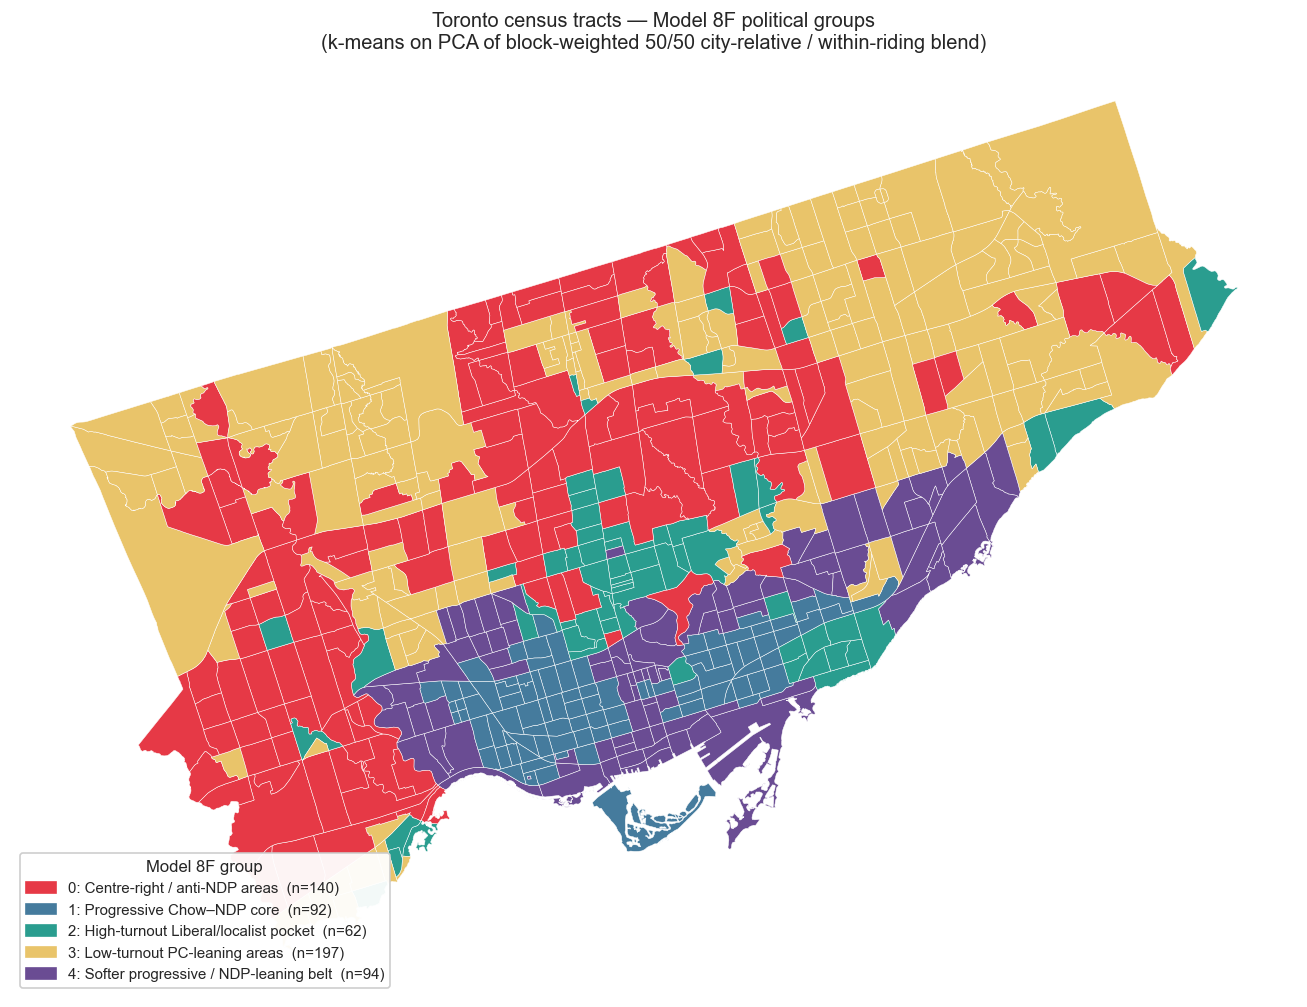

In [21]:
fig, ax = plt.subplots(figsize=(11, 12))
cmap_8f = mcolors.ListedColormap(PALETTE[:K_CHOSEN])
tracts.plot(column="cluster_8f", ax=ax, categorical=True, cmap=cmap_8f, edgecolor="white", linewidth=0.3, legend=False)
patches = [mpatches.Patch(color=PALETTE[c], label=f"{c}: {CLUSTER_LABELS[c]}  (n={cluster_sizes_8f[c]})") for c in range(K_CHOSEN)]
ax.legend(handles=patches, loc="lower left", fontsize=9, framealpha=0.95, title="Model 8F group")
ax.set_title("Toronto census tracts — Model 8F political groups\n"
             "(k-means on PCA of block-weighted 50/50 city-relative / within-riding blend)", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.show()


**Reading this.** The map is not a clean "downtown left, suburbs right" picture.
Cluster 1 (Progressive Chow–NDP core, blue) and Cluster 4 (Softer progressive/NDP-leaning
belt, purple) do sit where a conventional story would expect them — the old City of Toronto,
hugging the downtown core and the lake east toward the Beaches. But Cluster 0 (Centre-right /
anti-NDP, red) is not purely an outer-suburban story: alongside a large block across Etobicoke,
it also forms a dense, contiguous mass across a central-north swath (roughly the former City of
North York / midtown corridor) — a centre-right pattern sitting well inside the old inner
suburbs, not out at the city's edge. Cluster 3 (Low-turnout PC-leaning areas, yellow) is the
group that actually reads as classically suburban/exurban: it dominates the far northwest, the
far northeast (Scarborough), and fills in much of the space between the other groups. Cluster 2
(High-turnout Liberal/localist pocket, teal) shows up as smaller patches threaded through and
around the downtown/midtown area rather than a single bloc — consistent with a
locally-anchored rather than broadly geographic identity.

In [22]:
# ── Cluster composition by ward / provincial riding / federal riding ─────────────
def geography_tables(tracts, geo_col, geo_label):
    ct = pd.crosstab(tracts[geo_col], tracts["cluster_8f"])
    ct.columns = [f"{c}: {CLUSTER_LABELS[c]}" for c in ct.columns]
    share_within_geo = ct.div(ct.sum(axis=1), axis=0) * 100      # "what % of this geography is cluster c"
    share_of_cluster = ct.div(ct.sum(axis=0), axis=1) * 100      # "what % of cluster c sits in this geography"
    return ct, share_within_geo, share_of_cluster

ward_counts, ward_share_within, ward_share_of_cluster = geography_tables(tracts, "ward_label", "ward")
prov_counts, prov_share_within, prov_share_of_cluster = geography_tables(tracts, "prov_riding", "provincial riding")
fed_counts,  fed_share_within,  fed_share_of_cluster  = geography_tables(tracts, "fed_riding",  "federal riding")

print(f"Wards: {tracts['ward_label'].nunique()}  |  Provincial ridings: {tracts['prov_riding'].nunique()}  |  "
      f"Federal ridings: {tracts['fed_riding'].nunique()}")
ward_counts


Wards: 25  |  Provincial ridings: 25  |  Federal ridings: 24


,0: Centre-right / anti-NDP areas,1: Progressive Chow–NDP core,2: High-turnout Liberal/localist pocket,3: Low-turnout PC-leaning areas,4: Softer progressive / NDP-leaning belt
ward_label,,,,,
Ward 1,8,0,0,14,0
Ward 10,0,8,0,0,14
Ward 11,0,13,1,0,10
Ward 12,4,4,13,0,3
Ward 13,0,7,1,0,12
Ward 14,0,19,0,0,9
Ward 15,10,0,10,3,0
Ward 16,9,0,3,8,0
Ward 17,10,0,2,12,0


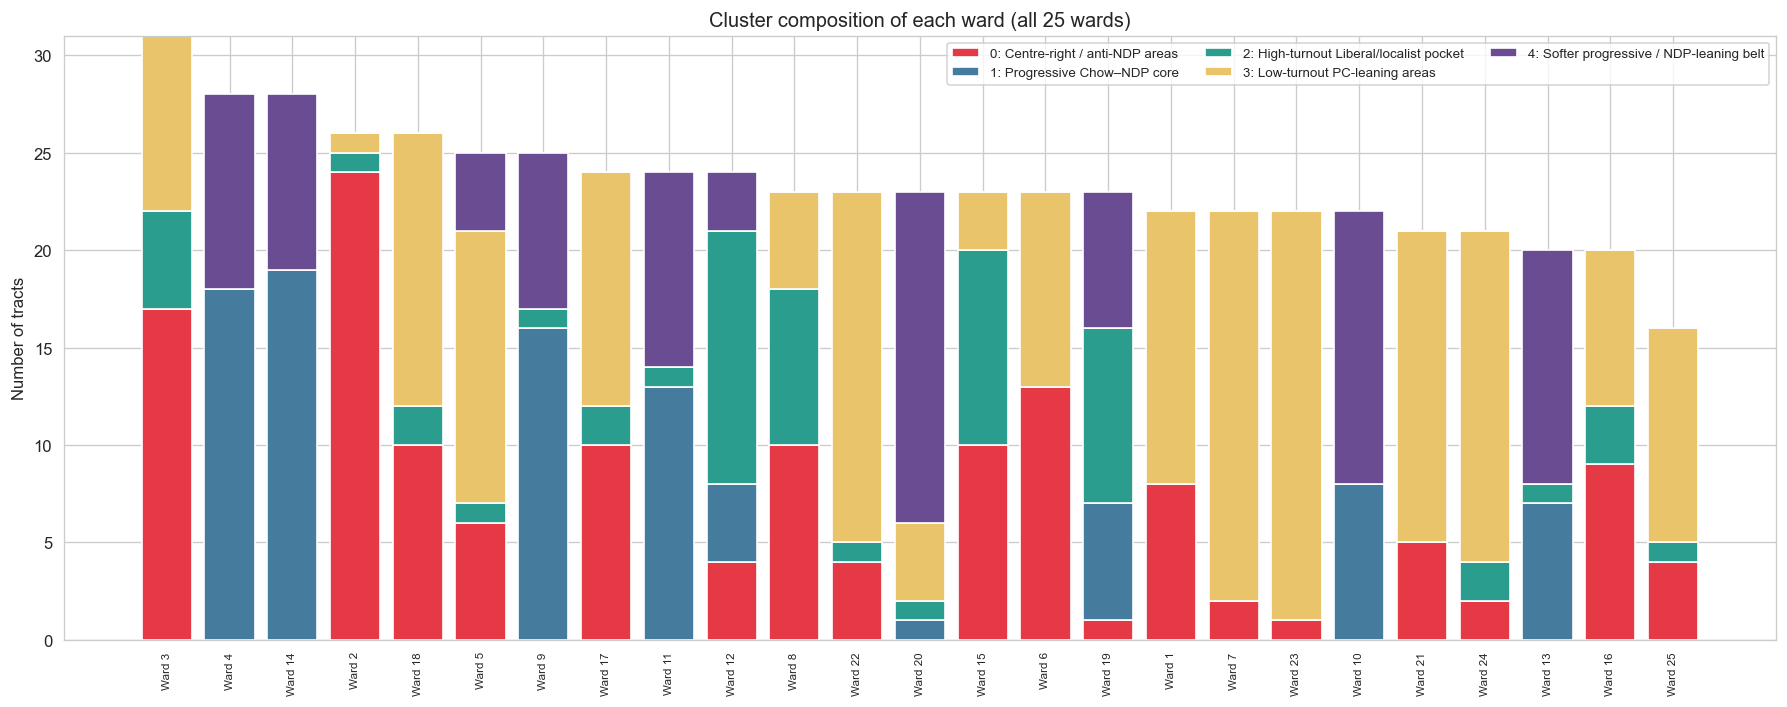

In [23]:
# ── Stacked bar: cluster composition of each ward, sorted by size ────────────────
fig, ax = plt.subplots(figsize=(15, 6))
plot_wards = ward_counts.loc[ward_counts.sum(axis=1).sort_values(ascending=False).index]
bottom = np.zeros(len(plot_wards))
for c in range(K_CHOSEN):
    vals = plot_wards[f"{c}: {CLUSTER_LABELS[c]}"].values
    ax.bar(range(len(plot_wards)), vals, bottom=bottom, color=PALETTE[c], label=f"{c}: {CLUSTER_LABELS[c]}")
    bottom += vals
ax.set_xticks(range(len(plot_wards))); ax.set_xticklabels(plot_wards.index, rotation=90, fontsize=7)
ax.set_ylabel("Number of tracts"); ax.set_title("Cluster composition of each ward (all 25 wards)")
ax.legend(fontsize=8, ncol=3, loc="upper right")
plt.tight_layout()
plt.show()


**Reading this.** The ward chart shows both patterns at once, depending on the ward.
A handful of wards are close to single-cluster: Ward 2 is almost entirely Cluster 0, Wards 4 and
14 are almost entirely Clusters 1+4 (the two progressive-leaning groups), and Wards 7 and 23 are
almost entirely Cluster 3. But most wards in the middle of the chart — Ward 18, Ward 5, Ward 12,
Ward 8, Ward 6, Ward 19, Ward 16 — are genuine three- or four-cluster mixes, with no single group
holding a majority of that ward's tracts. So the honest read is: **the extremes of the model
(the strongest progressive wards and the most suburban, low-turnout wards) are close to
riding-shaped, but the broad middle of the city is not** — which is exactly the kind of nuance a
single-race, ward-level election map would flatten out.

In [24]:
# ── Top geographies for each cluster (by share of cluster's tracts) ──────────────
def top_geographies_table(share_of_cluster, top_n=5):
    out = {}
    for col in share_of_cluster.columns:
        top = share_of_cluster[col].sort_values(ascending=False).head(top_n)
        out[col] = [f"{geo} ({pct:.0f}%)" for geo, pct in top.items()]
    return pd.DataFrame(out).T

print("Top wards per cluster (share of that cluster's tracts found there):")
display_ward = top_geographies_table(ward_share_of_cluster)
display_ward


Top wards per cluster (share of that cluster's tracts found there):


,0,1,2,3,4
0: Centre-right / anti-NDP areas,Ward 2 (17%),Ward 3 (12%),Ward 6 (9%),Ward 15 (7%),Ward 8 (7%)
1: Progressive Chow–NDP core,Ward 14 (21%),Ward 4 (20%),Ward 9 (17%),Ward 11 (14%),Ward 10 (9%)
2: High-turnout Liberal/localist pocket,Ward 12 (21%),Ward 15 (16%),Ward 19 (15%),Ward 8 (13%),Ward 3 (8%)
3: Low-turnout PC-leaning areas,Ward 23 (11%),Ward 7 (10%),Ward 22 (9%),Ward 24 (9%),Ward 21 (8%)
4: Softer progressive / NDP-leaning belt,Ward 20 (18%),Ward 10 (15%),Ward 13 (13%),Ward 4 (11%),Ward 11 (11%)


In [25]:
print("Top provincial ridings per cluster:")
top_geographies_table(prov_share_of_cluster)


Top provincial ridings per cluster:


,0,1,2,3,4
0: Centre-right / anti-NDP areas,Etobicoke Centre (17%),Etobicoke—Lakeshore (12%),York Centre (9%),Don Valley West (7%),Eglinton—Lawrence (7%)
1: Progressive Chow–NDP core,Toronto—Danforth (21%),Parkdale—High Park (20%),Davenport (17%),University—Rosedale (14%),Spadina—Fort York (9%)
2: High-turnout Liberal/localist pocket,Toronto—St. Paul's (21%),Don Valley West (16%),Beaches—East York (15%),Eglinton—Lawrence (13%),Etobicoke—Lakeshore (8%)
3: Low-turnout PC-leaning areas,Scarborough North (11%),Humber River—Black Creek (10%),Scarborough—Agincourt (9%),Scarborough—Guildwood (9%),Scarborough Centre (8%)
4: Softer progressive / NDP-leaning belt,Scarborough Southwest (18%),Spadina—Fort York (15%),Toronto Centre (13%),Parkdale—High Park (11%),University—Rosedale (11%)


In [26]:
print("Top federal ridings per cluster:")
top_geographies_table(fed_share_of_cluster)


Top federal ridings per cluster:


,0,1,2,3,4
0: Centre-right / anti-NDP areas,Etobicoke Centre (15%),Etobicoke—Lakeshore (11%),York Centre (9%),Don Valley North (8%),Scarborough Centre—Don Valley East (8%)
1: Progressive Chow–NDP core,Taiaiako’n—Parkdale—High Park (21%),Toronto—Danforth (21%),University—Rosedale (18%),Davenport (17%),Toronto Centre (8%)
2: High-turnout Liberal/localist pocket,Toronto—St. Paul's (26%),Don Valley West (18%),Beaches—East York (15%),Eglinton—Lawrence (13%),Etobicoke—Lakeshore (6%)
3: Low-turnout PC-leaning areas,Scarborough North (13%),Humber River—Black Creek (10%),Scarborough—Agincourt (10%),Scarborough—Woburn (10%),Willowdale (7%)
4: Softer progressive / NDP-leaning belt,Scarborough Southwest (18%),Toronto Centre (14%),Taiaiako’n—Parkdale—High Park (13%),Davenport (12%),Spadina—Harbourfront (12%)


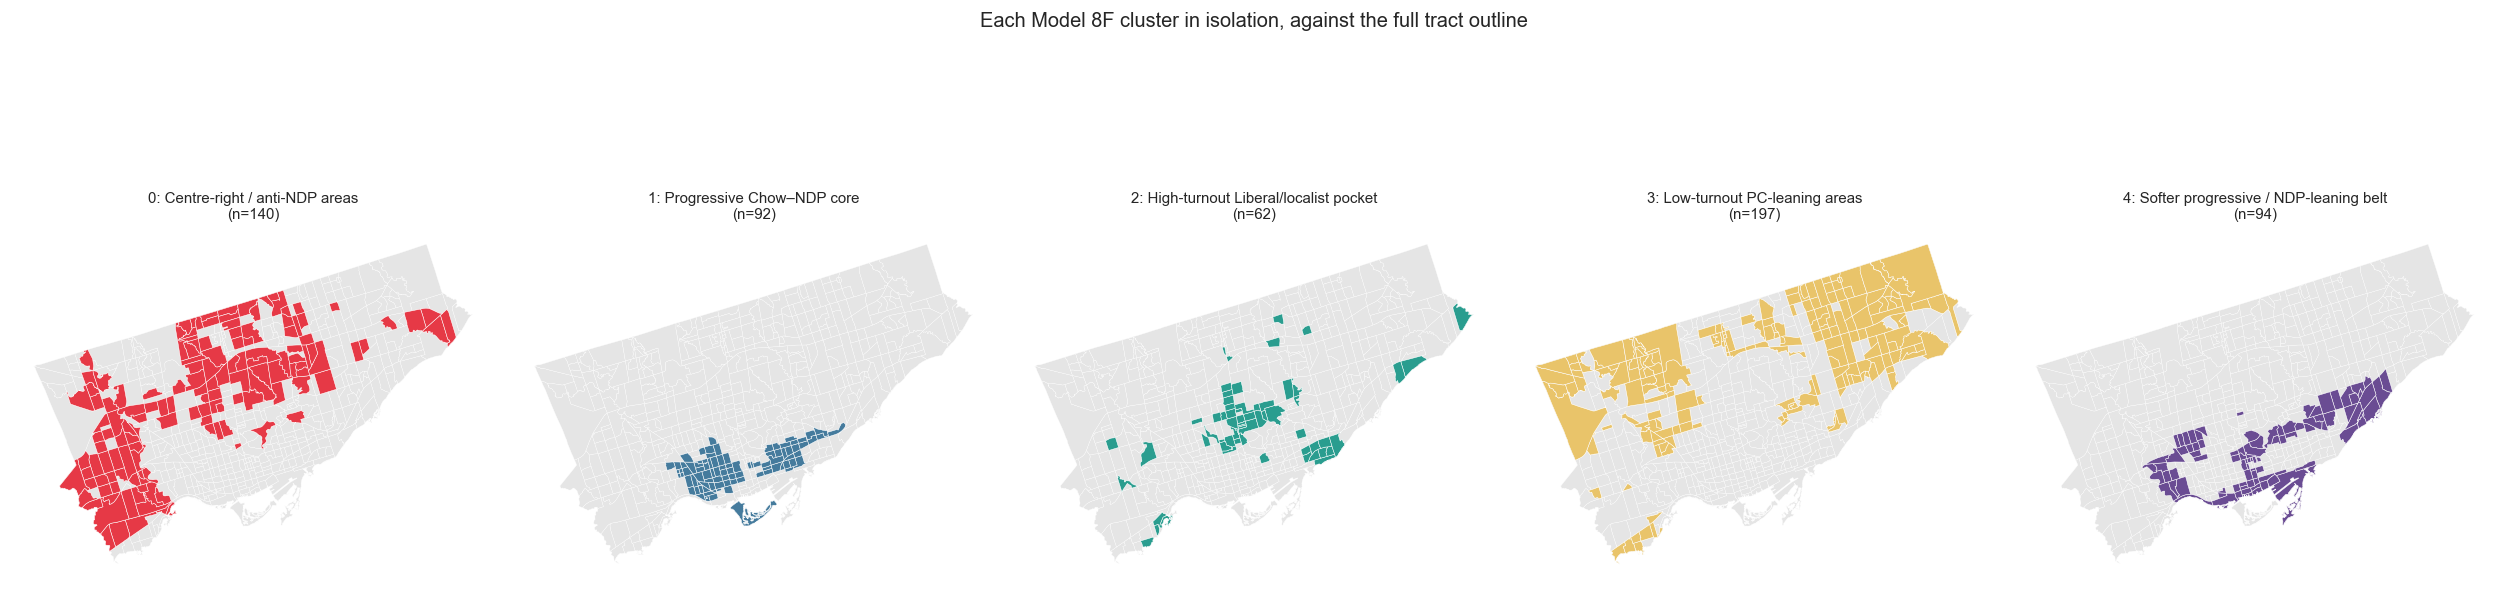

In [27]:
# ── Small maps isolating each cluster ─────────────────────────────────────────────
fig, axes = plt.subplots(1, K_CHOSEN, figsize=(4.2 * K_CHOSEN, 6))
for c, ax in zip(range(K_CHOSEN), axes):
    tracts.plot(ax=ax, color="#e5e5e5", edgecolor="white", linewidth=0.2)
    tracts[tracts["cluster_8f"] == c].plot(ax=ax, color=PALETTE[c], edgecolor="white", linewidth=0.3)
    ax.set_title(f"{c}: {CLUSTER_LABELS[c]}\n(n={cluster_sizes_8f[c]})", fontsize=9)
    ax.axis("off")
fig.suptitle("Each Model 8F cluster in isolation, against the full tract outline", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


**Reading this.** The five clusters differ sharply in spatial coherence:

- **Cluster 1 (Progressive core)** and **Cluster 4 (Softer progressive belt)** are the most
  spatially coherent — each forms one compact, contiguous band along the downtown lakefront
  (Cluster 4 wrapping around Cluster 1 to its north and east), reading as a genuine, unified
  "old city" corridor rather than scattered pockets.
- **Cluster 0 (Centre-right/anti-NDP)** is mostly one large contiguous mass spanning Etobicoke
  and a central-north swath, with a couple of smaller detached islands elsewhere — still
  reasonably coherent, but not a single unbroken shape.
- **Cluster 3 (Low-turnout PC-leaning)** is the largest group and forms several large,
  internally contiguous blobs (far northwest, far northeast/Scarborough, and a broad
  north-central swath) rather than one connected region — coherent within each of those areas,
  but split across three separate parts of the city.
- **Cluster 2 (Liberal/localist pocket)** is clearly the most fragmented of the five: a cluster
  of adjoining tracts in midtown plus several small, standalone one- or two-tract islands
  scattered near the core, in the far east tip, and in the southwest. This fits the story told
  in §3–§4: it is defined more by a specific local/candidate pattern than by a single
  contiguous political geography, so a fragmented footprint is expected rather than a modelling
  concern.

## 6. Loading and Reshaping the Census ADA Data

`data/clustering_neighbourhoods/census/toronto-ada.csv` is a **long-form** 2021 Census file:
one row per (geography, characteristic) pair, where the geography is an **ADA** (Aggregate
Dissemination Area — a StatCan geography slightly coarser than a census tract, used because
some census tables are only released at that level to protect confidentiality). We first
inspect the file directly, then reshape our chosen characteristics into a wide table.


In [28]:
census_long = pd.read_csv(CENSUS_ADA_CSV)
print(f"Rows: {len(census_long)}  |  Unique ADAs (GEO_NAME): {census_long['GEO_NAME'].nunique()}  |  "
      f"Unique characteristics: {census_long['CHARACTERISTIC_ID'].nunique()}")
print(f"Duplicate (GEO_NAME, CHARACTERISTIC_ID) rows: {census_long.duplicated(['GEO_NAME', 'CHARACTERISTIC_ID']).sum()}")
print(f"GEO_NAME dtype: {census_long['GEO_NAME'].dtype}  |  sample values: {sorted(census_long['GEO_NAME'].unique())[:5]}")
census_long.head(3)


Rows: 51336  |  Unique ADAs (GEO_NAME): 279  |  Unique characteristics: 184
Duplicate (GEO_NAME, CHARACTERISTIC_ID) rows: 0
GEO_NAME dtype: int64  |  sample values: [np.int64(35200001), np.int64(35200002), np.int64(35200003), np.int64(35200004), np.int64(35200005)]


,GEO_NAME,CHARACTERISTIC_ID,CHARACTERISTIC_NAME,CHARACTERISTIC_CODE,C1_COUNT_TOTAL,C10_RATE_TOTAL
0,35200001,1,"Population, 2021",pop_2021,5547.0,NaN
1,35200001,2,"Population, 2016",pop_2016,5806.0,NaN
2,35200001,3,"Population percentage change, 2016 to 2021",pop_pct_change,-4.5,-4.5


In [29]:
# Confirm the specific characteristic IDs requested in the brief actually exist with the
# names/codes expected, rather than assuming.
requested = census_long[census_long["CHARACTERISTIC_ID"].isin(CENSUS_CHAR_IDS)][
    ["CHARACTERISTIC_ID", "CHARACTERISTIC_NAME", "CHARACTERISTIC_CODE"]
].drop_duplicates().sort_values("CHARACTERISTIC_ID").reset_index(drop=True)
print(f"{len(requested)} of {len(CENSUS_CHAR_IDS)} requested characteristic IDs found.")
requested


24 of 24 requested characteristic IDs found.


,CHARACTERISTIC_ID,CHARACTERISTIC_NAME,CHARACTERISTIC_CODE
0,1,"Population, 2021",pop_2021
1,6,Population density per square kilometre,pop_density
2,37,65 years and over,age_65_over
3,39,Average age of the population,age_mean
4,50,Total - Private households by household size -...,pvt_house_total
5,57,Average household size,pvt_house_avg_size
6,113,Median total income in 2020 among recipien...,income_total_median
7,1414,Total - Private households by tenure - 25% sam...,housing_tenure_total
8,1416,Renter,housing_tenure_renter
9,1465,Total - Owner and tenant households with house...,housing_shelter_total


### Checking the commute-mode and commute-duration denominators

The brief asks us not to compute commute percentages without confirming the denominator. The
IDs immediately around the requested commute variables show the totals we need:


In [30]:
commute_context = census_long[(census_long["CHARACTERISTIC_ID"] >= 2598) & (census_long["CHARACTERISTIC_ID"] <= 2620)][
    ["CHARACTERISTIC_ID", "CHARACTERISTIC_NAME", "CHARACTERISTIC_CODE"]
].drop_duplicates().sort_values("CHARACTERISTIC_ID")
commute_context


,CHARACTERISTIC_ID,CHARACTERISTIC_NAME,CHARACTERISTIC_CODE
170,2603,Total - Main mode of commuting for the employe...,commute_mode_total
171,2604,"Car, truck or van",commute_mode_car_truck_van
172,2605,"Car, truck or van - as a driver",commute_mode_car_driver
173,2606,"Car, truck or van - as a passenger",commute_mode_car_passenger
174,2607,Public transit,commute_mode_transit
175,2608,Walked,commute_mode_walked
176,2609,Bicycle,commute_mode_bicycle
177,2610,Other method,commute_mode_other
178,2611,Total - Commuting duration for the employed la...,commute_duration_total
179,2612,Less than 15 minutes,commute_duration_under15


**Confirmed:** `commute_mode_total` (ID 2603) is the correct denominator for car/truck/van
(2604) and public-transit (2607) shares; `commute_duration_total` (ID 2611) is the correct
denominator for the 60-minutes-and-over share (2616). Both are distinct universes (main mode of
commuting vs. commuting duration) even though they happen to carry the same total count for most
ADAs in this data.

### A data quirk worth flagging: `age_65_over` is not a raw count

Checking characteristic IDs 34–40 shows `age_65_over` (ID 37) sits inside a **distribution-of-
population-by-age-group (%)** block — ID 34's value is 100.0 for every ADA, confirming the
whole block is percentages, not head counts. So `age_65_over`'s value in this file is already
"% of the ADA population aged 65+", not a count. Every other requested variable *is* a genuine
additive count (verified below), so we handle this one variable differently: we reconstruct an
implied head count as `age_65_over_pct / 100 * pop_2021` before aggregating, so that cluster-
level percentages are still population-weighted rather than an unweighted average of ADA
percentages.


In [31]:
# Sanity-check that every other requested "count" variable is genuinely additive, by confirming
# its published rate matches count/denominator to within rounding.
CENSUS_VARS = [
    # name                          id     kind        numerator                    denominator
    ("pop_2021",                    1,     "count",    "pop_2021",                  None),
    ("pop_density",                 6,     "density",  "pop_density",               None),
    ("age_65_over_pct",             37,    "pct_only", "age_65_over",                "pop_2021"),   # see note above
    ("age_mean",                    39,    "avg_pop_weighted", "age_mean",           "pop_2021"),
    ("pvt_house_total",             50,    "count",    "pvt_house_total",            None),
    ("pvt_house_avg_size",          57,    "avg_hh_weighted",  "pvt_house_avg_size",  "pvt_house_total"),
    ("income_total_median",        113,    "median_approx",    "income_total_median","pop_2021"),
    ("housing_tenure_total",      1414,    "count",    "housing_tenure_total",       None),
    ("housing_tenure_renter",     1416,    "count",    "housing_tenure_renter",      "housing_tenure_total"),
    ("housing_shelter_total",     1465,    "count",    "housing_shelter_total",      None),
    ("housing_shelter_30plus",    1467,    "count",    "housing_shelter_30plus",     "housing_shelter_total"),
    ("citizen_total",             1522,    "count",    "citizen_total",              None),
    ("citizen_canadian",          1523,    "count",    "citizen_canadian",           "citizen_total"),
    ("visible_minority_total",    1683,    "count",    "visible_minority_total",     None),
    ("visible_minority_yes",      1684,    "count",    "visible_minority_yes",       "visible_minority_total"),
    ("mobility_total",            1983,    "count",    "mobility_total",             None),
    ("mobility_migrants",         1987,    "count",    "mobility_migrants",          "mobility_total"),
    ("education_total",           1998,    "count",    "education_total",           None),
    ("education_bachelor_higher", 2008,    "count",    "education_bachelor_higher",  "education_total"),
    ("commute_mode_total",        2603,    "count",    "commute_mode_total",         None),
    ("commute_mode_car_truck_van",2604,    "count",    "commute_mode_car_truck_van", "commute_mode_total"),
    ("commute_mode_transit",      2607,    "count",    "commute_mode_transit",       "commute_mode_total"),
    ("commute_duration_total",    2611,    "count",    "commute_duration_total",     None),
    ("commute_duration_60plus",   2616,    "count",    "commute_duration_60plus",    "commute_duration_total"),
]
var_dict = pd.DataFrame(CENSUS_VARS, columns=["output_variable", "characteristic_id", "kind", "numerator_code", "denominator_code"])
var_dict["cluster_aggregation"] = var_dict["kind"].map({
    "count":              "sum numerator across cluster's ADAs",
    "density":            "sum(population) / sum(area_km2); area_km2 backed out per §Density note",
    "pct_only":           "reconstruct count = pct/100 * pop_2021, then sum(count) / sum(pop_2021)",
    "avg_pop_weighted":   "population-weighted average of ADA values",
    "avg_hh_weighted":    "household-weighted average of ADA values",
    "median_approx":      "population-weighted average of ADA medians (NOT a true cluster median — see caveat)",
})
var_dict


,output_variable,characteristic_id,kind,numerator_code,denominator_code,cluster_aggregation
0,pop_2021,1,count,pop_2021,None,sum numerator across cluster's ADAs
1,pop_density,6,density,pop_density,None,sum(population) / sum(area_km2); area_km2 back...
2,age_65_over_pct,37,pct_only,age_65_over,pop_2021,"reconstruct count = pct/100 * pop_2021, then s..."
3,age_mean,39,avg_pop_weighted,age_mean,pop_2021,population-weighted average of ADA values
4,pvt_house_total,50,count,pvt_house_total,None,sum numerator across cluster's ADAs
5,pvt_house_avg_size,57,avg_hh_weighted,pvt_house_avg_size,pvt_house_total,household-weighted average of ADA values
6,income_total_median,113,median_approx,income_total_median,pop_2021,population-weighted average of ADA medians (NO...
7,housing_tenure_total,1414,count,housing_tenure_total,None,sum numerator across cluster's ADAs
8,housing_tenure_renter,1416,count,housing_tenure_renter,housing_tenure_total,sum numerator across cluster's ADAs
9,housing_shelter_total,1465,count,housing_shelter_total,None,sum numerator across cluster's ADAs


In [32]:
# ── Build the wide ADA-level table ────────────────────────────────────────────────
code_list = [v[3] for v in CENSUS_VARS if v[3] != "pop_density"] + ["pop_density"]  # dedupe pop_2021 reused as den
code_list = sorted(set(code_list))
ada_wide = census_long[census_long["CHARACTERISTIC_CODE"].isin(code_list)].pivot(
    index="GEO_NAME", columns="CHARACTERISTIC_CODE", values="C1_COUNT_TOTAL"
)
ada_wide.index.name = "ada_id"
missing = ada_wide.isna().sum()
print("Missing values per column (0 expected for this variable set):")
print(missing[missing > 0].to_string() if missing.any() else "  none")

# Reconstruct the implied 65+ head count from the published percentage (see note above).
ada_wide["age_65_over_count"] = ada_wide["age_65_over"] / 100.0 * ada_wide["pop_2021"]

print(f"\nWide ADA table: {ada_wide.shape[0]} ADAs x {ada_wide.shape[1]} columns")
ada_wide.head(3)


Missing values per column (0 expected for this variable set):
  none

Wide ADA table: 279 ADAs x 25 columns


CHARACTERISTIC_CODE,age_65_over,age_mean,citizen_canadian,citizen_total,commute_duration_60plus,commute_duration_total,commute_mode_car_truck_van,commute_mode_total,commute_mode_transit,education_bachelor_higher,...,income_total_median,mobility_migrants,mobility_total,pop_2021,pop_density,pvt_house_avg_size,pvt_house_total,visible_minority_total,visible_minority_yes,age_65_over_count
ada_id,,,,,,,,,,,,,,,,,,,,,
35200001,11.8,38.3,4900.0,5540.0,395.0,2070.0,1610.0,2070.0,395.0,1225.0,...,36000.0,430.0,5285.0,5547.0,278.6,3.6,1525.0,5535.0,5255.0,654.546
35200002,13.3,38.9,10835.0,12480.0,570.0,4255.0,3620.0,4255.0,510.0,2695.0,...,34400.0,1055.0,11895.0,12479.0,1964.4,4.1,3075.0,12480.0,12255.0,1659.707
35200003,24.4,45.4,7655.0,9310.0,395.0,2675.0,2115.0,2675.0,465.0,1880.0,...,28200.0,1075.0,8920.0,9313.0,1980.3,2.9,3230.0,9305.0,8865.0,2272.372


## 7. Joining Census Data to the 8F Clusters

**We already have an exact crosswalk**, so there is no need to invent one:
`data/toronto_election_turnout/census/processed/crosswalks/statcan_2021_toronto_da_ct_ada_crosswalk.csv`
maps every dissemination area (DA) to its parent census tract (CT) and parent ADA. We use it at
the (CT, ADA) level, dropping the DA granularity we don't need here.

**Nesting check, stated explicitly (per the brief's request):** every census tract in this
data belongs to **exactly one** ADA (verified below) — tracts nest cleanly inside ADAs, never
the reverse. An ADA can, however, contain **more than one** tract. For those split ADAs, the
census file gives us one set of numbers for the whole ADA with no further breakdown, so we
**disaggregate by land area**: each child tract receives a share of its parent ADA's counts
proportional to that tract's share of the combined area of all tracts in that ADA. This is an
explicit modelling assumption — it treats population and every other count as **uniformly
distributed across the ADA's land area** — not a measured fact. It matters only for the tracts
inside a split ADA; whole-ADA tracts (the majority) get their parent ADA's numbers exactly, with
no assumption involved. We flag this plainly rather than presenting cluster-level demographics
as more precise than they are.


In [33]:
crosswalk = pd.read_csv(CT_ADA_CROSSWALK_CSV)
crosswalk["ct_id"] = crosswalk["ct_id"].map(lambda x: f"{x:.2f}")   # match clustered_tracts.gpkg's ct_id format
ct_to_ada = crosswalk[["ct_id", "ada_id"]].drop_duplicates()

n_ada_per_ct = ct_to_ada.groupby("ct_id")["ada_id"].nunique()
n_ct_per_ada = ct_to_ada.groupby("ada_id")["ct_id"].nunique()
print(f"Tracts mapping to more than one ADA (should be 0 if nesting holds): {(n_ada_per_ct > 1).sum()}")
print(f"ADAs split across multiple tracts: {(n_ct_per_ada > 1).sum()} of {len(n_ct_per_ada)} "
      f"({100 * (n_ct_per_ada > 1).mean():.0f}%)")
print(f"Largest split: one ADA spans {n_ct_per_ada.max()} tracts")


Tracts mapping to more than one ADA (should be 0 if nesting holds): 0
ADAs split across multiple tracts: 220 of 279 (79%)
Largest split: one ADA spans 7 tracts


In [34]:
# ── Area-weighted allocation of each ADA's census values to its child tract(s) ───
tracts_area = tracts[["ct_id", "geometry"]].merge(ct_to_ada, on="ct_id", how="left")
tracts_area["area_km2"] = tracts_area.to_crs(3347).geometry.area / 1e6   # Stats Canada Lambert, for area in km^2
tracts_area["ada_total_area_km2"] = tracts_area.groupby("ada_id")["area_km2"].transform("sum")
tracts_area["area_frac"] = tracts_area["area_km2"] / tracts_area["ada_total_area_km2"]

n_unmatched_ct = tracts_area["ada_id"].isna().sum()
n_unmatched_ada = len(set(ada_wide.index.astype(str)) - set(ct_to_ada["ada_id"].astype(str)))
print(f"Tracts with no ADA match: {n_unmatched_ct} of {len(tracts_area)}")
print(f"ADAs in the census file with no tract match: {n_unmatched_ada} of {ada_wide.shape[0]}")

# Count-type variables to allocate by area share (percent/average-type variables are handled
# separately below, since they should NOT be split by area — they get inherited as-is and
# re-weighted using the allocated counts).
ALLOCATE_COLS = [
    "pop_2021", "age_65_over_count", "pvt_house_total", "housing_tenure_total", "housing_tenure_renter",
    "housing_shelter_total", "housing_shelter_30plus", "citizen_total", "citizen_canadian",
    "visible_minority_total", "visible_minority_yes", "mobility_total", "mobility_migrants",
    "education_total", "education_bachelor_higher", "commute_mode_total", "commute_mode_car_truck_van",
    "commute_mode_transit", "commute_duration_total", "commute_duration_60plus",
]
CARRY_COLS = ["age_mean", "pvt_house_avg_size", "income_total_median"]   # non-additive; carried, re-weighted at aggregation

ct_census = tracts_area.merge(ada_wide.reset_index(), on="ada_id", how="left")
for col in ALLOCATE_COLS:
    ct_census[col] = ct_census[col] * ct_census["area_frac"]

# Conservation check: allocated tract-level sums must reproduce the ADA-level totals exactly.
pop_allocated, pop_source = ct_census["pop_2021"].sum(), ada_wide["pop_2021"].sum()
print(f"\nPopulation conservation check: allocated total = {pop_allocated:,.0f}  |  "
      f"source ADA total = {pop_source:,.0f}  |  match: {np.isclose(pop_allocated, pop_source)}")


Tracts with no ADA match: 0 of 585
ADAs in the census file with no tract match: 0 of 279

Population conservation check: allocated total = 2,794,356  |  source ADA total = 2,794,356  |  match: True


### QA: coverage of the join


In [35]:
qa = pd.DataFrame({
    "metric": [
        "ADAs in census file", "ADAs matched to >=1 tract", "ADAs unmatched",
        "Tracts total", "Tracts with census coverage", "Tracts without census coverage",
        "Population covered (allocated)", "Population in source census file",
    ],
    "value": [
        ada_wide.shape[0], ada_wide.shape[0] - n_unmatched_ada, n_unmatched_ada,
        len(tracts_area), len(tracts_area) - n_unmatched_ct, n_unmatched_ct,
        f"{pop_allocated:,.0f}", f"{pop_source:,.0f}",
    ],
})
qa


,metric,value
0,ADAs in census file,279
1,ADAs matched to >=1 tract,279
2,ADAs unmatched,0
3,Tracts total,585
4,Tracts with census coverage,585
5,Tracts without census coverage,0
6,Population covered (allocated),"2,794,356"
7,Population in source census file,"2,794,356"


In [36]:
# Coverage by cluster: population and tract counts, joined onto the cluster labels.
ct_census = ct_census.merge(tracts[["ct_id", "cluster_8f", "cluster_label"]], on="ct_id", how="left")
coverage_by_cluster = ct_census.groupby("cluster_label").agg(
    n_tracts=("ct_id", "count"),
    population_covered=("pop_2021", "sum"),
).reindex([CLUSTER_LABELS[c] for c in range(K_CHOSEN)])
coverage_by_cluster["pct_of_city_population"] = 100 * coverage_by_cluster["population_covered"] / pop_allocated
coverage_by_cluster.round(1)


,n_tracts,population_covered,pct_of_city_population
cluster_label,,,
Centre-right / anti-NDP areas,140,718804.5,25.7
Progressive Chow–NDP core,92,356465.8,12.8
High-turnout Liberal/localist pocket,62,278546.5,10.0
Low-turnout PC-leaning areas,197,931863.6,33.3
Softer progressive / NDP-leaning belt,94,508675.6,18.2


## 8. Demographic Profile of Each Cluster

We now aggregate the tract-level (area-allocated) census data up to the five 8F clusters,
following the rules in the brief: counts are **summed** then divided (never averaged as
percentages), density is derived from summed population over summed area, and the two genuine
averages (mean age, household size) are aggregate-weighted rather than simple means of ADA
values. Median income is flagged as an approximation — see the caveat below.


In [37]:
def aggregate_demographics(df, weight_pop="pop_2021"):
    # df: tract-level rows (area-allocated counts + carried averages) for one group.
    # Returns a dict of cluster-level demographic statistics.
    pop = df[weight_pop].sum()
    out = {
        "population": pop,
        "area_km2": df["area_km2"].sum(),
        "pop_density_per_km2": pop / df["area_km2"].sum() if df["area_km2"].sum() > 0 else np.nan,
        "pct_age_65_over": 100 * df["age_65_over_count"].sum() / pop,
        "avg_age": np.average(df["age_mean"], weights=df[weight_pop]),
        "avg_household_size": np.average(df["pvt_house_avg_size"], weights=df["pvt_house_total"]),
        "median_income_approx": np.average(df["income_total_median"], weights=df[weight_pop]),
        "pct_renter": 100 * df["housing_tenure_renter"].sum() / df["housing_tenure_total"].sum(),
        "pct_shelter_burdened_30plus": 100 * df["housing_shelter_30plus"].sum() / df["housing_shelter_total"].sum(),
        "pct_canadian_citizen": 100 * df["citizen_canadian"].sum() / df["citizen_total"].sum(),
        "pct_visible_minority": 100 * df["visible_minority_yes"].sum() / df["visible_minority_total"].sum(),
        "pct_migrant_5yr": 100 * df["mobility_migrants"].sum() / df["mobility_total"].sum(),
        "pct_bachelor_or_higher": 100 * df["education_bachelor_higher"].sum() / df["education_total"].sum(),
        "pct_commute_car": 100 * df["commute_mode_car_truck_van"].sum() / df["commute_mode_total"].sum(),
        "pct_commute_transit": 100 * df["commute_mode_transit"].sum() / df["commute_mode_total"].sum(),
        "pct_commute_60plus_min": 100 * df["commute_duration_60plus"].sum() / df["commute_duration_total"].sum(),
    }
    return out

demo_rows = {CLUSTER_LABELS[c]: aggregate_demographics(ct_census[ct_census["cluster_8f"] == c]) for c in range(K_CHOSEN)}
demo_rows["Toronto (all tracts)"] = aggregate_demographics(ct_census)
demographics = pd.DataFrame(demo_rows).T
demographics


,population,area_km2,pop_density_per_km2,pct_age_65_over,avg_age,avg_household_size,median_income_approx,pct_renter,pct_shelter_burdened_30plus,pct_canadian_citizen,pct_visible_minority,pct_migrant_5yr,pct_bachelor_or_higher,pct_commute_car,pct_commute_transit,pct_commute_60plus_min
Centre-right / anti-NDP areas,7.188045e+05,225.653639,3185.432801,20.111015,43.198538,2.556783,42618.242981,39.947710,29.928110,84.836884,48.886553,13.811366,40.299644,70.047682,22.055025,11.597727
Progressive Chow–NDP core,3.564658e+05,43.421601,8209.411920,14.465556,40.716169,2.093832,43860.556406,56.413311,33.030622,87.145406,38.815851,16.887779,48.211602,42.731435,29.210389,9.730828
High-turnout Liberal/localist pocket,2.785465e+05,50.147137,5554.584023,17.923952,42.164285,2.192634,52007.220445,48.097151,31.748657,86.251727,36.906586,16.138211,52.636869,57.156721,27.341735,9.788055
Low-turnout PC-leaning areas,9.318636e+05,266.564084,3495.833170,17.150171,41.004015,2.734129,33601.825762,45.339807,31.812737,78.719651,77.348573,15.894924,30.077188,67.255368,26.787399,15.452553
Softer progressive / NDP-leaning belt,5.086756e+05,80.165667,6345.305251,13.987530,40.080595,2.004452,47512.908135,55.156789,36.177804,82.025883,47.457197,22.933515,50.434827,47.884404,28.922508,10.682113
Toronto (all tracts),2.794356e+06,665.952129,4196.031331,17.070750,41.479364,2.382838,41596.839522,48.065865,32.466715,82.715151,55.670941,16.789523,41.068222,60.962898,26.238052,12.462964


**Caveat on `median_income_approx`:** published medians cannot be summed or exactly re-derived
from smaller geographies. This is a **population-weighted average of ADA-level medians**, a
reasonable approximation of central tendency but *not* a recomputed true median for the
cluster — treat it as directionally informative, not exact.

**Caveat on the area-weighted allocation (§7):** every number above for a cluster inherits
whatever error the area-based split introduces for ADAs that straddle a cluster boundary. This
mainly affects mixed-cluster ADAs; whole-ADA-inside-one-cluster tracts are unaffected.


In [38]:
# ── Comparison to the Toronto-wide benchmark: difference, rank, and index (Toronto = 100) ──
toronto_row = demographics.loc["Toronto (all tracts)"]
cluster_demo = demographics.drop(index="Toronto (all tracts)")
cluster_demo.index = range(K_CHOSEN)   # align to cluster IDs 0..4 in order

comparison_frames = {}
for col in cluster_demo.columns:
    diff = cluster_demo[col] - toronto_row[col]
    rank = cluster_demo[col].rank(ascending=False).astype(int)
    index100 = 100 * cluster_demo[col] / toronto_row[col]
    comparison_frames[col] = pd.DataFrame({
        "cluster_value": cluster_demo[col], "toronto_value": toronto_row[col],
        "diff_vs_toronto": diff, "rank_1_is_highest": rank, "index_toronto_100": index100,
    })

# A single flat table: one row per (cluster, variable), for later filtering/plotting.
demo_long = pd.concat(
    {col: frame for col, frame in comparison_frames.items()}, names=["variable", "cluster"]
).reset_index()
demo_long["cluster_label"] = demo_long["cluster"].map(CLUSTER_LABELS)
demo_long.head(8)


,variable,cluster,cluster_value,toronto_value,diff_vs_toronto,rank_1_is_highest,index_toronto_100,cluster_label
0,population,0,718804.504787,2.794356e+06,-2.075551e+06,2,25.723441,Centre-right / anti-NDP areas
1,population,1,356465.811115,2.794356e+06,-2.437890e+06,4,12.756636,Progressive Chow–NDP core
2,population,2,278546.487781,2.794356e+06,-2.515810e+06,5,9.968182,High-turnout Liberal/localist pocket
3,population,3,931863.567611,2.794356e+06,-1.862492e+06,1,33.348062,Low-turnout PC-leaning areas
4,population,4,508675.628705,2.794356e+06,-2.285680e+06,3,18.203680,Softer progressive / NDP-leaning belt
5,area_km2,0,225.653639,6.659521e+02,-4.402985e+02,2,33.884363,Centre-right / anti-NDP areas
6,area_km2,1,43.421601,6.659521e+02,-6.225305e+02,5,6.520229,Progressive Chow–NDP core
7,area_km2,2,50.147137,6.659521e+02,-6.158050e+02,4,7.530141,High-turnout Liberal/localist pocket


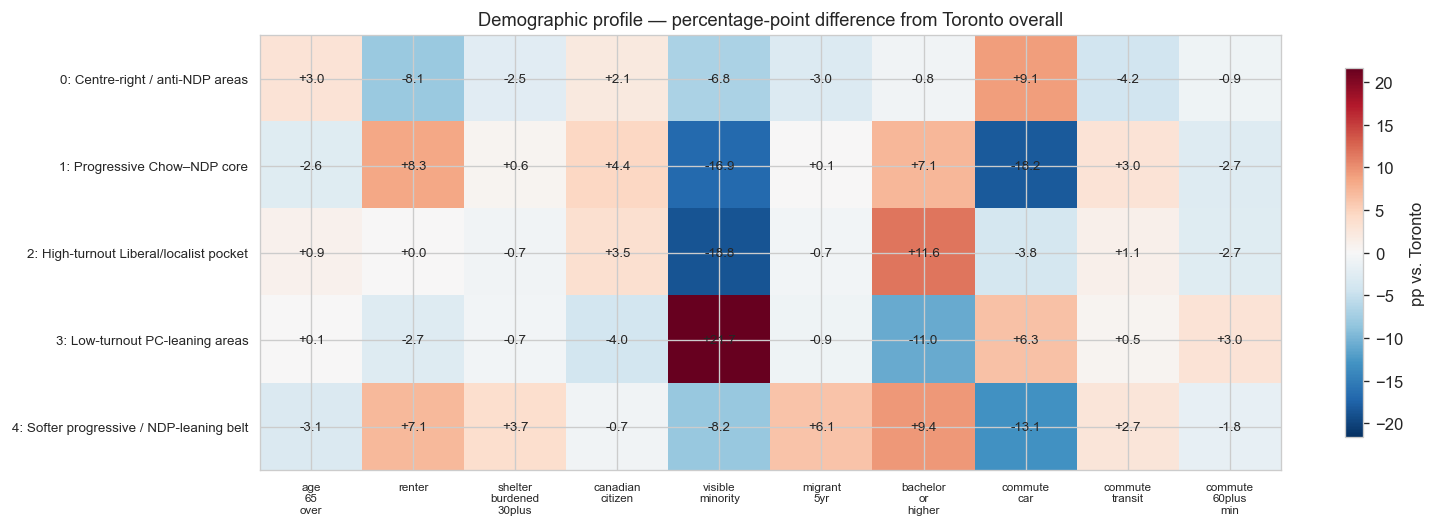

In [39]:
# ── Demographic heatmap: cluster deviation from Toronto, in standard-deviation-like index units ──
pct_vars = ["pct_age_65_over", "pct_renter", "pct_shelter_burdened_30plus", "pct_canadian_citizen",
            "pct_visible_minority", "pct_migrant_5yr", "pct_bachelor_or_higher",
            "pct_commute_car", "pct_commute_transit", "pct_commute_60plus_min"]
other_vars = ["pop_density_per_km2", "avg_age", "avg_household_size", "median_income_approx"]

heat_pct = pd.DataFrame({v: comparison_frames[v]["diff_vs_toronto"] for v in pct_vars})
heat_pct.index = [f"{c}: {CLUSTER_LABELS[c]}" for c in range(K_CHOSEN)]

fig, ax = plt.subplots(figsize=(13, 4.5))
vmax = np.abs(heat_pct.values).max()
im = ax.imshow(heat_pct.values, cmap="RdBu_r", aspect="auto", vmin=-vmax, vmax=vmax)
for i in range(heat_pct.shape[0]):
    for j in range(heat_pct.shape[1]):
        ax.text(j, i, f"{heat_pct.values[i, j]:+.1f}", ha="center", va="center", fontsize=8)
ax.set_xticks(range(len(pct_vars))); ax.set_xticklabels([v.replace("pct_", "").replace("_", "\n") for v in pct_vars], fontsize=7)
ax.set_yticks(range(len(heat_pct))); ax.set_yticklabels(heat_pct.index, fontsize=8)
ax.set_title("Demographic profile — percentage-point difference from Toronto overall", fontsize=11)
fig.colorbar(im, ax=ax, label="pp vs. Toronto", shrink=0.85)
plt.tight_layout()
plt.show()


**Reading this.** The clearest, most consistent pattern in this heatmap is **visible
minority share**, and it cuts in a specific direction: Clusters 1 and 2 (progressive core and
Liberal/localist pocket) sit far *below* the Toronto average (-16.9pp and -16.6pp), while
Cluster 3 (low-turnout PC-leaning, the largest group) sits far *above* it. We report this
because it is a real, large pattern in the aggregate tract data — but we are deliberately
neutral about what it means: it is an ecological, tract-level association alongside a
political-lean pattern, not a claim about how anyone voted or why, and Cluster 3's other
distinguishing features (below-average post-secondary attainment, below-average approximate
income in §8's bar charts, above-average car commuting) describe a broader outer-suburban
profile that visible-minority share is only one part of. Beyond that: renter share and
bachelor's-attainment move together with the progressive-leaning clusters (1, 2, and 4 all sit
above the city average on both), and car-commuting is the mirror image, running highest in
Clusters 0 and 3. Migrant share (5-year mobility) is close to the city average everywhere except
a modest excess in Cluster 4.

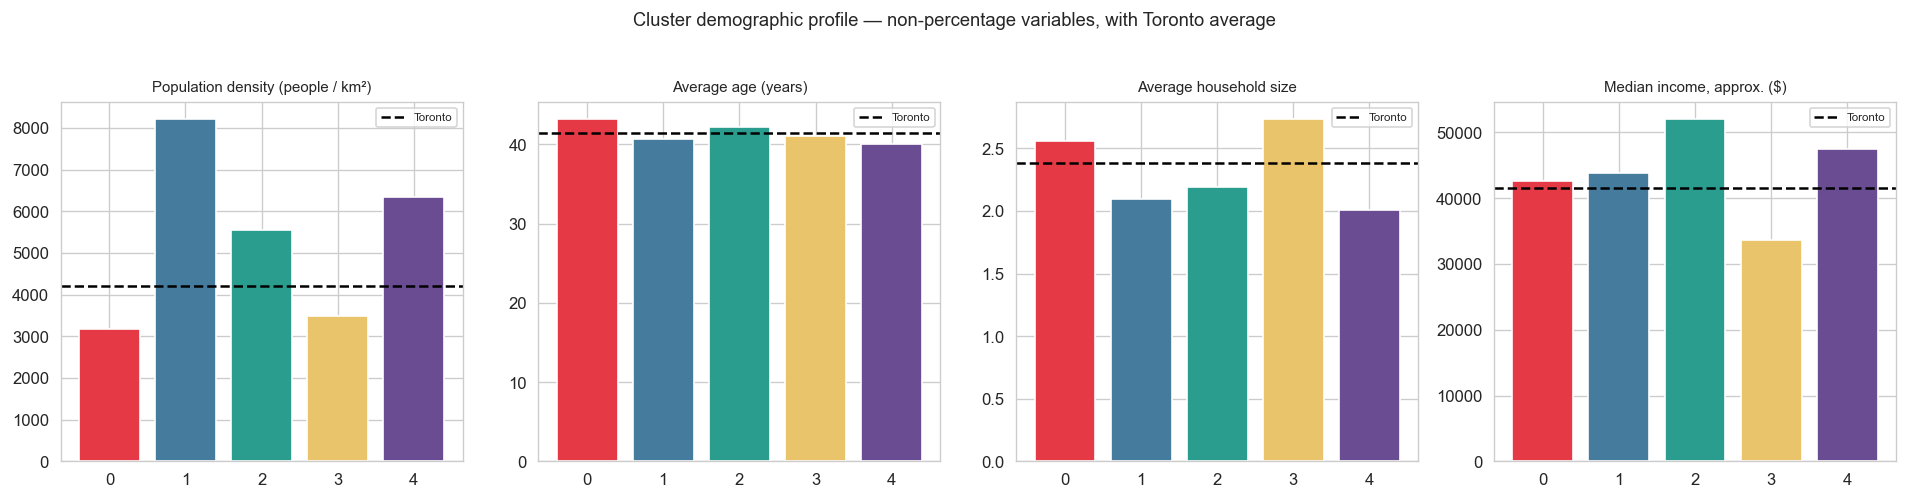

In [40]:
# ── Bar charts for the "other" (non-percentage) variables, each on its own natural scale ──
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = {"pop_density_per_km2": "Population density (people / km²)", "avg_age": "Average age (years)",
          "avg_household_size": "Average household size", "median_income_approx": "Median income, approx. ($)"}
for ax, col in zip(axes, other_vars):
    vals = cluster_demo[col]
    ax.bar(range(K_CHOSEN), vals.values, color=[PALETTE[c] for c in range(K_CHOSEN)])
    ax.axhline(toronto_row[col], color="black", lw=1.5, linestyle="--", label="Toronto")
    ax.set_xticks(range(K_CHOSEN)); ax.set_xticklabels(range(K_CHOSEN))
    ax.set_title(titles[col], fontsize=9)
    ax.legend(fontsize=7)
fig.suptitle("Cluster demographic profile — non-percentage variables, with Toronto average", fontsize=11, y=1.03)
plt.tight_layout()
plt.show()


**Reading this.** Cluster 1 (Progressive core) is by a wide margin the densest group
(~8,200 people/km², roughly double the citywide average) and has the smallest average
household size — a compact, high-density inner-city profile. Cluster 3 (Low-turnout
PC-leaning) and Cluster 0 (Centre-right/anti-NDP) are the two least-dense groups, both below
the citywide average, consistent with §5's map showing them anchored in the outer and
central-north parts of the city. On the two "other" measures: Cluster 2 (Liberal/localist
pocket) has the highest approximate median income of the five groups (~$52k vs. a citywide
~$42k), while Cluster 3 has the lowest (~$34k) alongside the largest average household size —
again, remembering that `median_income_approx` is the population-weighted average of published
ADA medians (§8's caveat), not a recomputed true cluster median. Average age is fairly flat
across all five groups, sitting within about two years of the citywide average in every case —
age is not a strong differentiator here, unlike density, income, or renter share.

### Vote profile vs. demographics, at the tract level

The cluster-level table above averages away a lot of tract-to-tract variation. As one more
diagnostic, we plot two specific tract-level relationships the story brief calls out —
**renter share vs. NDP/Chow strength**, and **population density vs. PC/Conservative
strength** — coloured by cluster. This is a **descriptive, ecological (tract-level)
correlation only**: it says nothing about how any individual voted, and correlation here is
not evidence of causation in either direction.


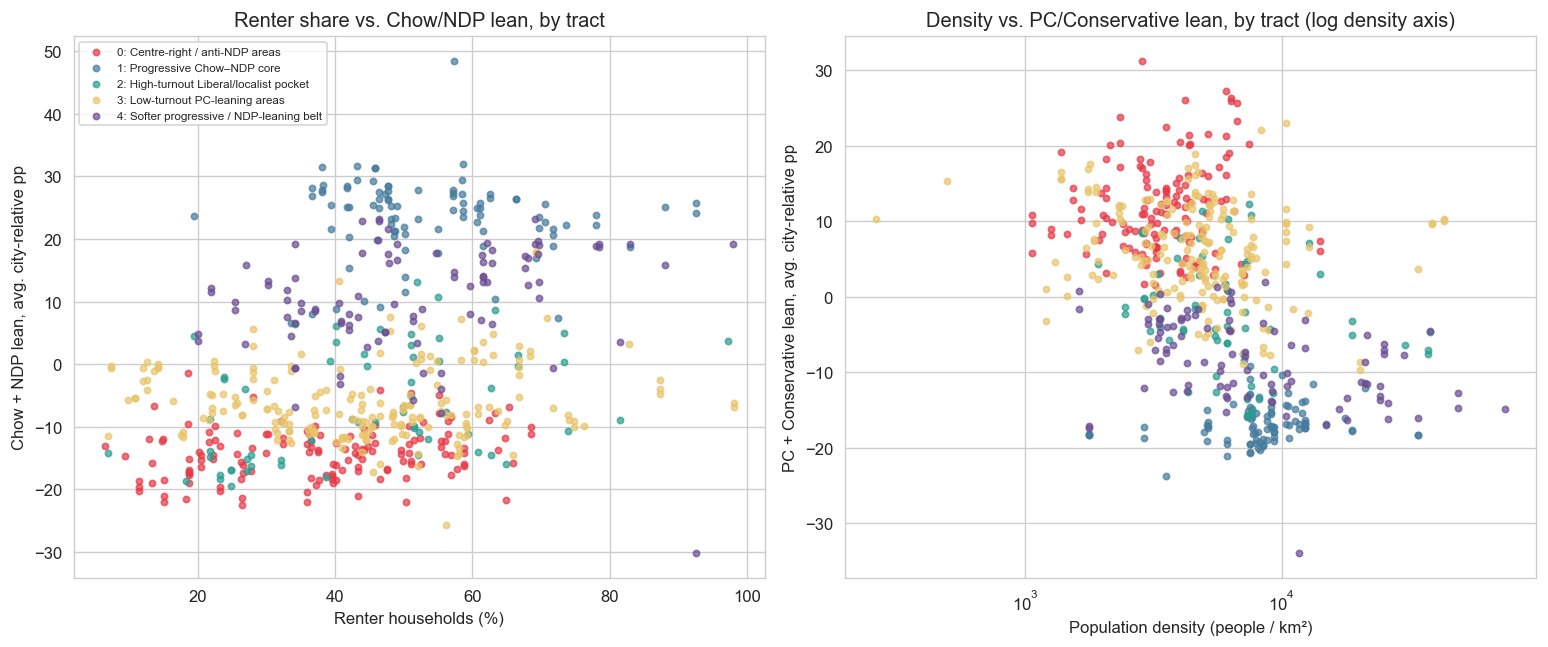

In [41]:
ct_census["pct_renter_tract"] = 100 * ct_census["housing_tenure_renter"] / ct_census["housing_tenure_total"]
ct_census["pop_density_tract"] = ct_census["pop_2021"] / ct_census["area_km2"]
tract_scatter = ct_census[["ct_id", "cluster_8f", "pct_renter_tract", "pop_density_tract"]].merge(
    tracts[["ct_id", "mun_chow_vs_city", "prov_ndp_vs_city", "prov_pc_vs_city", "fed_conservative_vs_city"]],
    on="ct_id", how="left",
)
tract_scatter["chow_ndp_lean_pp"] = 100 * (tract_scatter["mun_chow_vs_city"] + tract_scatter["prov_ndp_vs_city"]) / 2
tract_scatter["pc_con_lean_pp"]   = 100 * (tract_scatter["prov_pc_vs_city"] + tract_scatter["fed_conservative_vs_city"]) / 2

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for c in range(K_CHOSEN):
    mask = tract_scatter["cluster_8f"] == c
    axes[0].scatter(tract_scatter.loc[mask, "pct_renter_tract"], tract_scatter.loc[mask, "chow_ndp_lean_pp"],
                    color=PALETTE[c], s=14, alpha=0.7, label=f"{c}: {CLUSTER_LABELS[c]}")
    axes[1].scatter(tract_scatter.loc[mask, "pop_density_tract"], tract_scatter.loc[mask, "pc_con_lean_pp"],
                    color=PALETTE[c], s=14, alpha=0.7)
axes[0].set_xlabel("Renter households (%)"); axes[0].set_ylabel("Chow + NDP lean, avg. city-relative pp")
axes[0].set_title("Renter share vs. Chow/NDP lean, by tract")
axes[1].set_xlabel("Population density (people / km²)"); axes[1].set_ylabel("PC + Conservative lean, avg. city-relative pp")
axes[1].set_xscale("log")
axes[1].set_title("Density vs. PC/Conservative lean, by tract (log density axis)")
axes[0].legend(fontsize=7, loc="upper left")
plt.tight_layout()
plt.show()


**Reading this.** Both panels show a real but noisy ecological association, driven
mainly by where each cluster's tracts fall rather than a smooth citywide trend. In the left
panel, tracts under about 25% renter households are almost all Cluster 0 or Cluster 3 tracts
sitting well below the city average on Chow/NDP lean; tracts above about 60% renter households
skew heavily toward Cluster 1 and Cluster 4, well above average. In between, the colours mix
freely — mid-range renter shares do not reliably predict lean on their own. The right panel
shows the same shape in reverse: the lowest-density tracts (left edge, mostly Clusters 0 and 3)
lean PC/Conservative, while the highest-density tracts (right edge, mostly Clusters 1 and 4)
lean away from PC/Conservative, with a wide, mixed-colour middle density range in between. In
both cases the relationship looks like it is carried by the clusters that sit at the two
extremes of the demographic variable, not by a uniform city-wide slope — worth stating as "a
tendency at the extremes," not a general rule that holds tract-by-tract.

## 9. Electoral-Demographic Synthesis

Pulling §3–§8 together into one reference table — the backbone for the eventual article. Each
cell is generated from the actual computed numbers above, not written free-hand, so it stays
in sync if any upstream computation changes.


In [42]:
def political_signature(c):
    row = check_profiles.loc[f"50-50 {c}", SHARE_COLS]
    turn = check_profiles.loc[f"50-50 {c}", TURNOUT_COLS].mean()
    over = row.nlargest(2)
    under = row.nsmallest(2)
    turn_word = "above" if turn > 1 else ("below" if turn < -1 else "near")
    return (f"Over: {', '.join(f'{i} ({v:+.1f}pp)' for i, v in over.items())}. "
            f"Under: {', '.join(f'{i} ({v:+.1f}pp)' for i, v in under.items())}. "
            f"Turnout {turn_word} city average ({turn:+.1f}pp avg. across 3 elections).")

def demographic_signature(c, top_n=3):
    all_vars = pct_vars + other_vars
    spread = {v: (cluster_demo[v].max() - cluster_demo[v].min()) or np.nan for v in all_vars}
    z = pd.Series({v: (cluster_demo.loc[c, v] - toronto_row[v]) / spread[v] for v in all_vars})
    top = z.abs().sort_values(ascending=False).head(top_n).index
    parts = []
    for v in top:
        diff = cluster_demo.loc[c, v] - toronto_row[v]
        direction = "above" if diff > 0 else "below"
        parts.append(f"{v.replace('pct_', '').replace('_', ' ')} {direction} city avg. ({diff:+.1f})")
    return "; ".join(parts)

def top_geography(c, share_of_cluster, label):
    col = f"{c}: {CLUSTER_LABELS[c]}"
    top = share_of_cluster[col].sort_values(ascending=False).head(2)
    return f"{label}: " + ", ".join(f"{g} ({p:.0f}%)" for g, p in top.items())

CAVEATS = {
    0: "Turnout close to city average; distinguished mainly by partisan lean, not engagement.",
    1: "Highest turnout of the five groups in every election alongside the strongest NDP/Chow lean — "
       "engagement and progressive lean move together here, so the two are hard to fully separate.",
    2: "Partly shaped by a concentrated Matlow showing in specific 2023 municipal results (see reference "
       "notebook §9B); read as a genuine local/Liberal pattern, but with a local-candidate-effect caveat.",
    3: "The largest cluster and the softest boundary in the model (closest centroid to Cluster 0, §4) — "
       "turnout is the clearest distinguishing feature, not partisan intensity.",
    4: "A lower-intensity mirror of Cluster 1: same directional lean, smaller magnitude, average turnout.",
}

synthesis_rows = []
for c in range(K_CHOSEN):
    synthesis_rows.append({
        "cluster": c, "label": CLUSTER_LABELS[c], "n_tracts": int(cluster_sizes_8f[c]),
        "political_signature": political_signature(c),
        "demographic_signature": demographic_signature(c),
        "geography": top_geography(c, ward_share_of_cluster, "Wards") + " | " + top_geography(c, prov_share_of_cluster, "Prov. ridings"),
        "caveat": CAVEATS[c],
    })
synthesis_table = pd.DataFrame(synthesis_rows).set_index("cluster")
synthesis_table


,label,n_tracts,political_signature,demographic_signature,geography,caveat
cluster,,,,,,
0,Centre-right / anti-NDP areas,140,"Over: prov_pc (+12.9pp), fed_conservative (+10...",commute transit below city avg. (-4.2); avg ag...,"Wards: Ward 2 (17%), Ward 3 (12%) | Prov. ridi...",Turnout close to city average; distinguished m...
1,Progressive Chow–NDP core,92,"Over: prov_ndp (+30.1pp), mun_chow (+17.0pp). ...",pop density per km2 above city avg. (+4013.4);...,"Wards: Ward 14 (21%), Ward 4 (20%) | Prov. rid...",Highest turnout of the five groups in every el...
2,High-turnout Liberal/localist pocket,62,"Over: prov_liberal (+12.3pp), mun_matlow (+5.0...",median income approx above city avg. (+10410.4...,"Wards: Ward 12 (21%), Ward 15 (16%) | Prov. ri...",Partly shaped by a concentrated Matlow showing...
3,Low-turnout PC-leaning areas,197,"Over: prov_pc (+9.0pp), mun_other (+5.5pp). Un...",visible minority above city avg. (+21.7); comm...,"Wards: Ward 23 (11%), Ward 7 (10%) | Prov. rid...",The largest cluster and the softest boundary i...
4,Softer progressive / NDP-leaning belt,94,"Over: prov_ndp (+16.4pp), mun_chow (+4.3pp). U...",migrant 5yr above city avg. (+6.1); shelter bu...,"Wards: Ward 20 (18%), Ward 10 (15%) | Prov. ri...",A lower-intensity mirror of Cluster 1: same di...


*Cross-checked against §5's map/small-multiples and §8's heatmap: the automated `demographic_signature` values line up with what those sections show directly (e.g. Cluster 3's top signal here, visible-minority share, is the same standout feature the §8 heatmap flags; Cluster 1's density figure matches §8's bar chart). Treat this table as a data-checked starting point for the article's cluster-profile cards, not final copy — the wording still needs a journalist's pass.*

## 10. Representative and Boundary Tracts

For each cluster: which tracts sit closest to its centroid (the clearest, most archetypal
examples — useful for story anecdotes or interactive map callouts), and which tracts sit almost
equally close to a *different* cluster's centroid (the genuinely ambiguous, boundary cases,
useful for QA and for being upfront about where the model is less confident).


In [43]:
dist_to_centroids = np.linalg.norm(X_pca_8f[:, None, :] - centroids_pca[None, :, :], axis=-1)
dist_df = pd.DataFrame(dist_to_centroids, columns=range(K_CHOSEN))
dist_df["ct_id"] = raw_gdf["ct_id"].values
dist_df["cluster_8f"] = labels_8f
dist_df["dist_to_own_centroid"] = dist_df.apply(lambda r: r[r["cluster_8f"]], axis=1)

def second_nearest(row):
    others = row[[c for c in range(K_CHOSEN) if c != row["cluster_8f"]]]
    return others.idxmin(), others.min()

dist_df[["nearest_other_cluster", "dist_to_nearest_other"]] = dist_df.apply(
    lambda r: pd.Series(second_nearest(r)), axis=1
)
dist_df["margin"] = dist_df["dist_to_nearest_other"] - dist_df["dist_to_own_centroid"]

print("Representative tracts — closest to their own cluster centroid:")
representative = (
    dist_df.sort_values("dist_to_own_centroid")
    .groupby("cluster_8f").head(5)
    .sort_values(["cluster_8f", "dist_to_own_centroid"])
    [["ct_id", "cluster_8f", "dist_to_own_centroid", "margin"]]
)
representative["cluster_label"] = representative["cluster_8f"].map(CLUSTER_LABELS)
representative


Representative tracts — closest to their own cluster centroid:


,ct_id,cluster_8f,dist_to_own_centroid,margin,cluster_label
258,5350215.00,0,0.316161,0.498135,Centre-right / anti-NDP areas
257,5350214.00,0,0.328347,0.541362,Centre-right / anti-NDP areas
398,5350305.01,0,0.362770,0.427891,Centre-right / anti-NDP areas
530,5350372.00,0,0.390702,0.441459,Centre-right / anti-NDP areas
409,5350308.02,0,0.392745,0.384131,Centre-right / anti-NDP areas
34,5350026.00,1,0.353409,0.497750,Progressive Chow–NDP core
95,5350073.00,1,0.353697,0.759802,Progressive Chow–NDP core
93,5350072.01,1,0.359053,0.750718,Progressive Chow–NDP core
87,5350066.00,1,0.381513,0.605538,Progressive Chow–NDP core
126,5350099.00,1,0.383032,0.569585,Progressive Chow–NDP core


In [44]:
print("Boundary tracts — smallest margin between own cluster and the next-nearest cluster:")
boundary = (
    dist_df.sort_values("margin")
    .head(15)
    [["ct_id", "cluster_8f", "nearest_other_cluster", "dist_to_own_centroid", "dist_to_nearest_other", "margin"]]
    .copy()
)
boundary["cluster_label"] = boundary["cluster_8f"].map(CLUSTER_LABELS)
boundary["nearest_other_label"] = boundary["nearest_other_cluster"].map(CLUSTER_LABELS)
boundary


Boundary tracts — smallest margin between own cluster and the next-nearest cluster:


,ct_id,cluster_8f,nearest_other_cluster,dist_to_own_centroid,dist_to_nearest_other,margin,cluster_label,nearest_other_label
464,5350333.00,4,0.0,0.903402,0.901685,-0.001717,Softer progressive / NDP-leaning belt,Centre-right / anti-NDP areas
384,5350300.03,3,2.0,0.684221,0.683313,-0.000908,Low-turnout PC-leaning areas,High-turnout Liberal/localist pocket
313,5350250.01,0,3.0,0.704630,0.706753,0.002123,Centre-right / anti-NDP areas,Low-turnout PC-leaning areas
11,5350010.01,4,1.0,0.791630,0.794042,0.002412,Softer progressive / NDP-leaning belt,Progressive Chow–NDP core
443,5350318.01,3,0.0,0.649360,0.656240,0.006880,Low-turnout PC-leaning areas,Centre-right / anti-NDP areas
402,5350306.01,0,3.0,0.839820,0.849069,0.009249,Centre-right / anti-NDP areas,Low-turnout PC-leaning areas
482,5350346.02,3,4.0,0.775685,0.786117,0.010432,Low-turnout PC-leaning areas,Softer progressive / NDP-leaning belt
249,5350209.00,3,0.0,0.774918,0.789427,0.014509,Low-turnout PC-leaning areas,Centre-right / anti-NDP areas
199,5350167.02,2,1.0,0.969067,0.984567,0.015499,High-turnout Liberal/localist pocket,Progressive Chow–NDP core
170,5350136.02,4,2.0,0.942604,0.959606,0.017002,Softer progressive / NDP-leaning belt,High-turnout Liberal/localist pocket


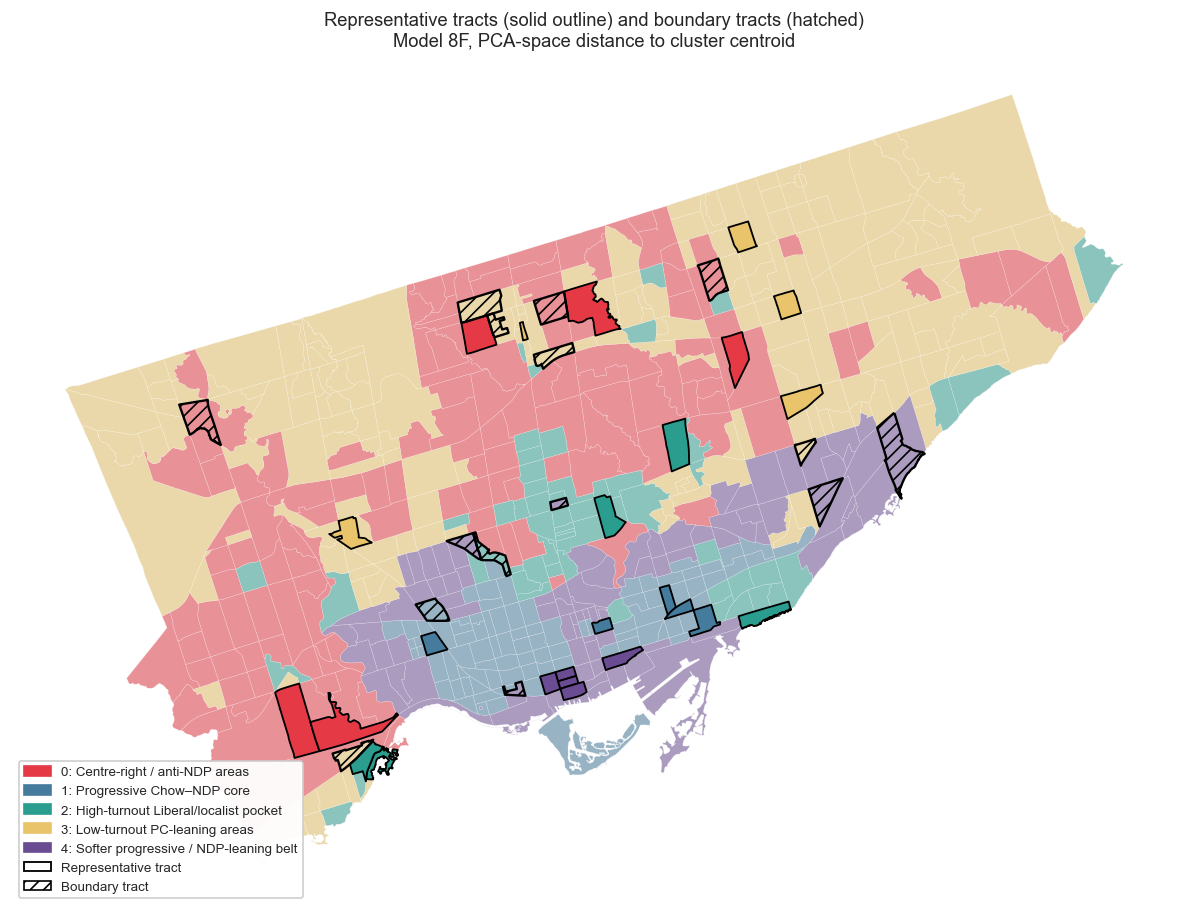

In [45]:
# ── Map: representative tracts (solid) vs. boundary tracts (hatched) ─────────────
fig, ax = plt.subplots(figsize=(10, 11))
tracts.plot(ax=ax, color="#ececec", edgecolor="white", linewidth=0.2)
plot_tracts = tracts.merge(dist_df[["ct_id", "margin"]], on="ct_id")
plot_tracts.plot(column="cluster_8f", ax=ax, categorical=True, cmap=mcolors.ListedColormap(PALETTE[:K_CHOSEN]),
                  edgecolor="white", linewidth=0.2, alpha=0.5)
rep_geo = tracts[tracts["ct_id"].isin(representative["ct_id"])]
rep_geo.plot(ax=ax, color=[PALETTE[c] for c in rep_geo["cluster_8f"]], edgecolor="black", linewidth=1.1)
bnd_geo = tracts[tracts["ct_id"].isin(boundary["ct_id"])]
bnd_geo.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.4, hatch="///")
handles = [mpatches.Patch(color=PALETTE[c], label=f"{c}: {CLUSTER_LABELS[c]}") for c in range(K_CHOSEN)] + [
    mpatches.Patch(facecolor="white", edgecolor="black", linewidth=1.1, label="Representative tract"),
    mpatches.Patch(facecolor="white", edgecolor="black", hatch="///", label="Boundary tract"),
]
ax.legend(handles=handles, loc="lower left", fontsize=8, framealpha=0.95)
ax.set_title("Representative tracts (solid outline) and boundary tracts (hatched)\nModel 8F, PCA-space distance to cluster centroid", fontsize=11)
ax.axis("off")
plt.tight_layout()
plt.show()


**Reading this.** The representative tracts broadly match each cluster's ward/riding
profile from §5: Cluster 0's textbook tracts sit in the central-north and southwest-lakeshore
areas that dominate its ward composition, Cluster 3's sit out in the areas it's concentrated in,
and Clusters 1/2/4's representative tracts cluster around the downtown/midtown corridor as
expected. The boundary tracts are not scattered randomly — most cluster in two specific places:
along the edge between Cluster 0 and Cluster 3 in the central-north part of the city, and along
the edge between the downtown cluster group (1, 2, 4) where they meet each other near the core.
The first pattern lines up exactly with §4's finding that Clusters 0 and 3 have the closest
centroids of any pair in the model — the map confirms that softest boundary is a real,
geographically contiguous seam, not a modelling artifact scattered across unrelated tracts.

In [46]:
# The IDs below are fixed by the west->east centroid sort in §2 and re-confirmed there on every
# run (the notebook asserts the reproduction matches the reference profile before proceeding) —
# safe to reference directly by number in the write-up prose that follows.
prog_core     = [c for c in range(K_CHOSEN) if CLUSTER_LABELS[c] == PROVISIONAL_LABELS[1]][0]
soft_prog     = [c for c in range(K_CHOSEN) if CLUSTER_LABELS[c] == PROVISIONAL_LABELS[4]][0]
centre_right  = [c for c in range(K_CHOSEN) if CLUSTER_LABELS[c] == PROVISIONAL_LABELS[0]][0]
low_turnout   = [c for c in range(K_CHOSEN) if CLUSTER_LABELS[c] == PROVISIONAL_LABELS[3]][0]
liberal_pocket= [c for c in range(K_CHOSEN) if CLUSTER_LABELS[c] == PROVISIONAL_LABELS[2]][0]
print(f"Progressive core = Cluster {prog_core}  |  Softer progressive belt = Cluster {soft_prog}")
print(f"Centre-right/anti-NDP = Cluster {centre_right}  |  Low-turnout PC-leaning = Cluster {low_turnout}")
print(f"High-turnout Liberal/localist pocket = Cluster {liberal_pocket}")


Progressive core = Cluster 1  |  Softer progressive belt = Cluster 4
Centre-right/anti-NDP = Cluster 0  |  Low-turnout PC-leaning = Cluster 3
High-turnout Liberal/localist pocket = Cluster 2


## 11. Story Implications

### The narrative arc

1. Election-night maps usually show one race at a time — mayor, or the provincial vote, or the
   federal vote — and hide how a tract's political character looks across *all three* at once.
2. Model 8F builds a single profile per tract by comparing it both to Toronto overall and to
   its own ward/riding, then groups tracts with similar profiles.
3. Five political neighbourhood types emerge — not the two-sided "downtown left, suburbs
   right" story Toronto political coverage usually reaches for.
4. **The left side splits in two**: a high-turnout progressive core (Cluster 1) and a softer,
   lower-intensity NDP-leaning belt (Cluster 4) that leans the same direction but far less
   sharply, at closer-to-average turnout.
5. **The right side also splits in two**: a centre-right/anti-NDP bloc (Cluster 0) and a
   low-turnout PC-leaning bloc (Cluster 3) that shares its partisan direction but is set apart
   mainly by being consistently the least-engaged group across all three elections — and, per
   §4, the softest boundary in the whole model.
6. **A fifth group cuts across the left-right frame entirely**: a smaller, high-turnout
   Liberal/localist pocket (Cluster 2) shaped as much by a specific municipal candidate's local
   strength as by ideology — evidence that local context and candidate quality still carve out
   real space on the map, even in a model built purely from ballots.
7. The demographic profiles in §8 describe *who lives in* each political Toronto — read as
   associations, not causes.
8. Throughout: these are **neighbourhood-level profiles of aggregate vote patterns**, not
   descriptions of individual voters, and they reflect a mix of turnout, local candidates,
   riding context, and durable political geography — not any one of those alone.

*(The `prog_core` / `soft_prog` / `centre_right` / `low_turnout` / `liberal_pocket` variables
computed just above confirm these are indeed Clusters 1, 4, 0, 3, and 2 respectively — re-check
this printout if the upstream pipeline is ever re-run with different inputs.)*

### Possible final article visuals

- Main Model 8F cluster map (§5)
- Cluster profile heatmap — city-relative deviations (§3)
- Actual vote-share heatmap (§3)
- Turnout-by-cluster comparison chart (§3)
- "Left side splits in two" map: Clusters 1 + 4 highlighted against the rest
- "Right side splits in two" map: Clusters 0 + 3 highlighted against the rest
- Demographic deviation-from-Toronto heatmap (§8)
- Cluster profile cards, one per group, combining §9's synthesis table with a small map inset
- Cluster composition by ward/riding stacked bar chart (§5)
- Representative-tract examples / boundary-tract map, for interactive callouts (§10)
